In [1]:
import struct as s
import array as array
import numpy as np
import os
import glob
#import utopya as ut
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.integrate import IntegrationWarning
import scipy.integrate as integrate
from scipy.optimize import curve_fit
from scipy.interpolate import griddata
from scipy.interpolate import interp1d
import scipy.integrate as integrate
import pandas as pd

LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
YEAR_MKS = 3.15569251e7
PARSEC_MKS = 3.085677581491367e16
VACUUM_PERMEABILITY_NORM = 1.00000000055
ELECTRON_MASS_MKS = 9.1093837139e-31
PROTON_MASS_MKS = 1.67262192369e-27
CMB_TEMPERATURE = 2.7255

EV_MKS = ELECTRON_CHARGE_MKS
MEGAPARSEC_MKS = 1e6 * PARSEC_MKS
PLANCK_CONSTANT_REDUCED_MKS = PLANCK_CONSTANT_MKS / (2.0 * np.pi)
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS*LIGHT_SPEED_MKS)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * LIGHT_SPEED_MKS
PROTON_REST_ENERGY_MKS = PROTON_MASS_MKS * LIGHT_SPEED_MKS * LIGHT_SPEED_MKS
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS*ELECTRON_CHARGE_MKS / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
CMB_ENERGY = BOLTZMANN_CONSTANT_MKS * CMB_TEMPERATURE
PLANCK_TIMES_LIGHT = PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS*ELECTRON_CHARGE_MKS / (2.0 * VACUUM_PERMITTIVITY * PLANCK_TIMES_LIGHT)
RY_ENERGY_MKS = FINE_STRUCTURE_CONSTANT*FINE_STRUCTURE_CONSTANT * ELECTRON_REST_ENERGY_MKS / 2.0
THOMSON_CROSS_SECTION_MKS = (8.0 * np.pi / 3.0) * ELECTRON_RADIUS_MKS * ELECTRON_RADIUS_MKS
BOHR_RADIUS_MKS = PLANCK_CONSTANT_REDUCED_MKS / (ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * FINE_STRUCTURE_CONSTANT)



PLANCK_CONSTANT_CGS = PLANCK_CONSTANT_MKS * 1.0e7
ELECTRON_MASS_CGS = ELECTRON_MASS_MKS * 1.0e3
ELECTRON_CHARGE_CGS = ELECTRON_CHARGE_MKS * 2.99792458e9    
LIGHT_SPEED_CGS = LIGHT_SPEED_MKS * 1.0e2
DIRAC_CONSTANT_CGS = PLANCK_CONSTANT_CGS / (2.0 * np.pi)

#Estructura del dataframe
ParticleType = np.dtype([('x', np.float64), ('y', np.float64), ('z', np.float64),
                            ('px', np.float64), ('py', np.float64), ('pz', np.float64), ('t', np.float64),
                            ('type', np.ubyte), ('state', np.ubyte), ('create', np.ubyte), ('destroy', np.ubyte), ('padding', np.int32)])



# --- 1. Publication-Quality Parameters ---
import matplotlib.pyplot as plt

# Paleta de colores de alto contraste (ej. tab10 o colorblind)
high_contrast_colors = plt.cm.tab10.colors

plt.rcParams.update({
    "text.usetex": True,                  # Fundamental para tipografía de tesis en física
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 14,                 # Letras legibles
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,                # Números claros
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "lines.linewidth": 2.0,               # Líneas más gruesas para contraste
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "-",
    "axes.prop_cycle": plt.cycler('color', high_contrast_colors)
})


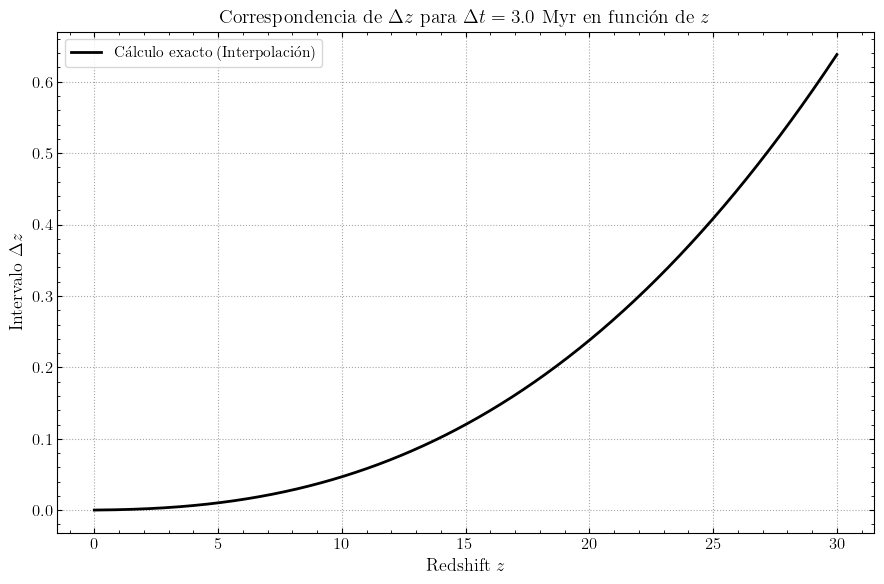

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18
from astropy import units as u
from scipy.interpolate import interp1d

def graficar_intervalo_redshift(tolerance_time_myr, z_min=0.0, z_max=30.0, num_points=1000):
    """
    Calcula y grafica el \delta_z correspondiente a un intervalo temporal 
    constante en Myr en función de z.
    
    Parámetros:
    -----------
    tolerance_time_myr : float
        Intervalo de tiempo en Mega años.
    z_min, z_max : float
        Rango de redshift para el eje x del gráfico.
    num_points : int
        Resolución del arreglo a graficar.
    """
    dt = tolerance_time_myr * u.Myr
    z_array = np.linspace(z_min, z_max, num_points)

    # ==========================================================
    # MÉTODO 1: Cálculo exacto (Interpolación de la edad cósmica)
    # ==========================================================
    # Se genera una grilla logarítmica de redshifts que cubra el rango necesario
    z_grid = np.geomspace(1e-5, 1500, 50000)
    z_grid = np.insert(z_grid, 0, 0.0)
    
    # Se evalúa la edad del universo en la grilla y se transforma a Myr
    age_grid = Planck18.age(z_grid).to(u.Myr).value
    
    # Para interpelar Age -> z con scipy, el dominio X (age) debe ser creciente.
    # Como la edad disminuye con z, invertimos el orden de los arreglos.
    age_to_z = interp1d(age_grid[::-1], z_grid[::-1], 
                        kind='cubic', bounds_error=False, fill_value=np.nan)

    # Edad en cada z a evaluar
    age_at_z = Planck18.age(z_array).to(u.Myr).value
    
    # Restamos el delta temporal (ir al pasado implica universo más joven, por lo tanto sumamos a z)
    age_target = age_at_z - tolerance_time_myr

    # Obtenemos los redshifts correspondientes y calculamos el \delta_z
    z_target = age_to_z(age_target)
    delta_z_exact = z_target - z_array
    # ==========================================================
    # GRAFICACIÓN
    # ==========================================================
    plt.figure(figsize=(9, 6))
    
    plt.plot(z_array, delta_z_exact, label='Cálculo exacto (Interpolación)', 
             color='black', lw=2)

    plt.xlabel(r'Redshift $z$', fontsize=13)
    plt.ylabel(r'Intervalo $\Delta z$', fontsize=13)
    plt.title(rf'Correspondencia de $\Delta z$ para $\Delta t = {tolerance_time_myr}$ Myr en función de $z$', 
              fontsize=14)
    
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7, color='grey')
    plt.tight_layout()
    plt.show()

# Ejecución 
graficar_intervalo_redshift(tolerance_time_myr=3.0, z_min=0, z_max=30)

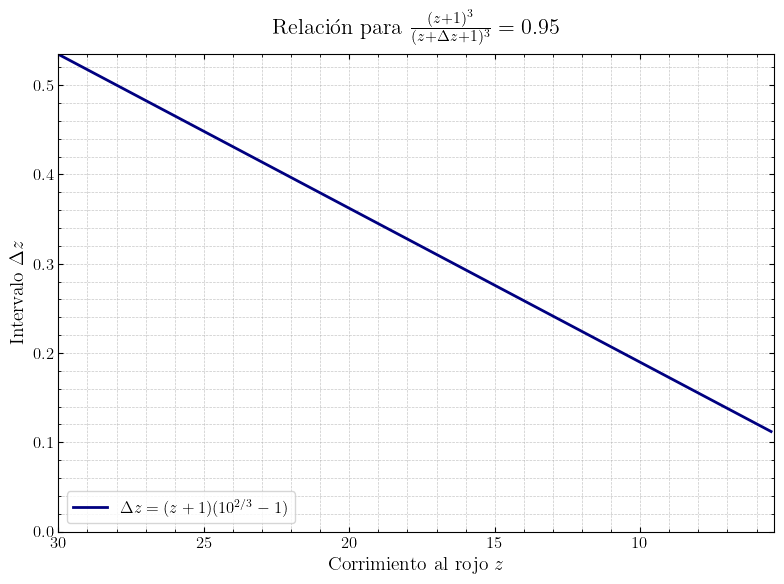

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_delta_z(z: np.ndarray, target_ratio: float = 0.95) -> np.ndarray:
    """
    Calcula el intervalo delta_z tal que (z+1)^3 / (z+delta_z+1)^3 = target_ratio
    """
    # Expresión analítica deducida de la condición
    factor = (1.0 / target_ratio)**(1.0/3.0) - 1.0
    return (z + 1.0) * factor

# Definir el arreglo de corrimiento al rojo (z)
# z = 0 (local) hasta z = 10 (época de reionización/High-z)
z_array = np.linspace(5.5, 30, 1000)

# Calcular Delta z
delta_z_array = calculate_delta_z(z_array)

# Configurar el estilo del gráfico
plt.figure(figsize=(8, 6))
plt.plot(z_array, delta_z_array, color='navy', lw=2, label=r'$\Delta z = (z+1)(10^{2/3} - 1)$')

# Detalles del gráfico
plt.xlabel(r'Corrimiento al rojo $z$', fontsize=14)
plt.ylabel(r'Intervalo $\Delta z$', fontsize=14)
plt.title(r'Relación para $\frac{(z+1)^3}{(z+\Delta z+1)^3} = 0.95$', fontsize=16, pad=15)

# Formato de los ejes y grilla
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlim(30, 5.4)
plt.ylim(0, max(delta_z_array))
plt.legend(fontsize=12, loc='lower left')

# Ajustar layout y mostrar
plt.tight_layout()
plt.show()

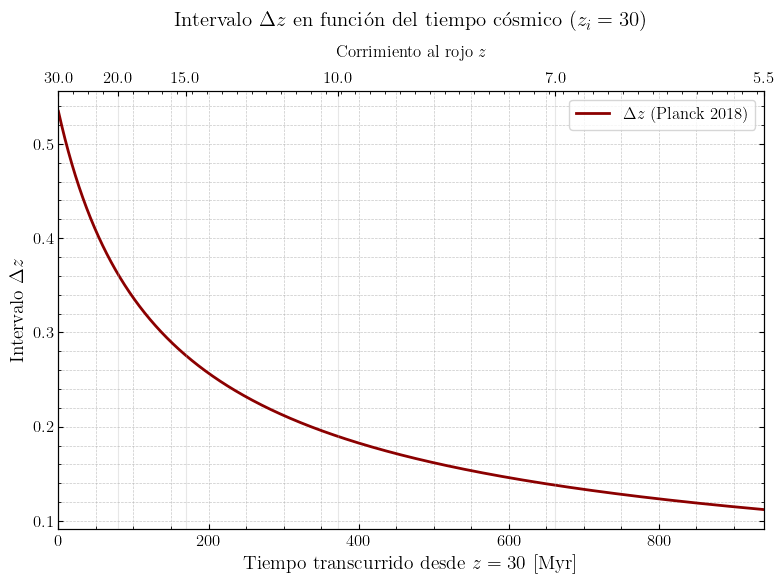

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18
import astropy.units as u

def calculate_delta_z(z: np.ndarray, target_ratio: float = 0.95) -> np.ndarray:
    """
    Calcula el intervalo delta_z tal que (z+1)^3 / (z+delta_z+1)^3 = target_ratio
    """
    factor = (1.0 / target_ratio)**(1.0/3.0) - 1.0
    return (z + 1.0) * factor

# Definir el arreglo de z desde 30 hasta 5.5 (evolución temporal hacia el presente)
z_array = np.linspace(30, 5.5, 1000)

# Calcular la edad del universo en z=30 y en cada z del arreglo (en Giga-años)
age_z30 = Planck18.age(30).to(u.Myr).value
age_z = Planck18.age(z_array).to(u.Myr).value

# Tiempo transcurrido desde z=30
time_elapsed = age_z - age_z30

# Calcular Delta z correspondiente a cada z
delta_z_array = calculate_delta_z(z_array)

# Configurar el gráfico
plt.figure(figsize=(8, 6))

# Se grafica Delta z en función del tiempo transcurrido
plt.plot(time_elapsed, delta_z_array, color='darkred', lw=2, 
         label=r'$\Delta z$ (Planck 2018)')

# Detalles del gráfico
plt.xlabel(r'Tiempo transcurrido desde $z=30$ [Myr]', fontsize=14)
plt.ylabel(r'Intervalo $\Delta z$', fontsize=14)
plt.title(r'Intervalo $\Delta z$ en función del tiempo cósmico ($z_i = 30$)', fontsize=15, pad=15)

# Formato de ejes
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlim(0, max(time_elapsed))
plt.legend(fontsize=12, loc='upper right')

# Añadir un eje secundario superior para mostrar valores de z de referencia
ax1 = plt.gca()
ax2 = ax1.twiny()

# Seleccionar algunos valores de z representativos para el eje secundario
z_ticks = np.array([30, 20,15,  10, 7 , 5.5])
# Interpolar para encontrar el tiempo transcurrido en esos valores de z
t_ticks = np.interp(z_ticks[::-1], z_array[::-1], time_elapsed[::-1])[::-1]

ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(t_ticks)
ax2.set_xticklabels([f'{z}' for z in z_ticks])
ax2.set_xlabel(r'Corrimiento al rojo $z$', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

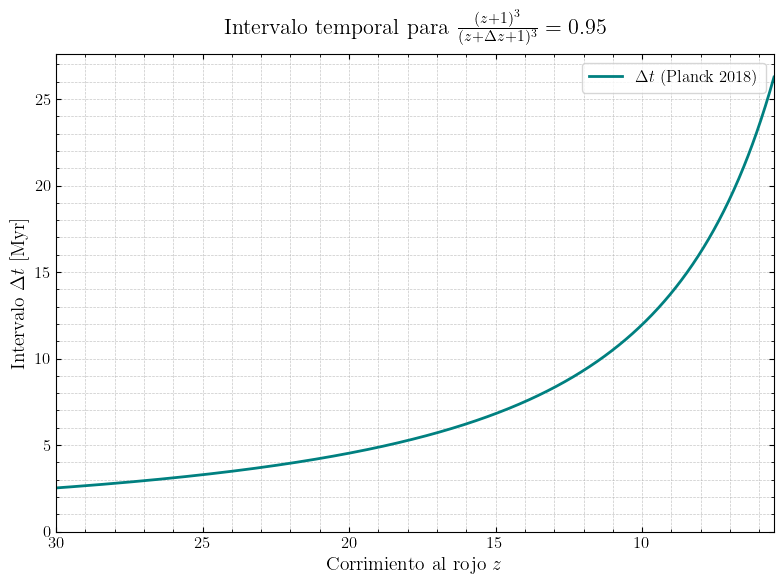

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18
import astropy.units as u

def calculate_delta_z(z: np.ndarray, target_ratio: float = 0.95) -> np.ndarray:
    """
    Calcula el intervalo delta_z tal que (z+1)^3 / (z+delta_z+1)^3 = target_ratio
    """
    factor = (1.0 / target_ratio)**(1.0/3.0) - 1.0
    return (z + 1.0) * factor

# Definir el arreglo de corrimiento al rojo (z)
z_array = np.linspace(5.5, 30, 1000)

# Calcular Delta z para el nuevo cociente
delta_z_array = calculate_delta_z(z_array)

# Evaluar la edad del universo en z y en z + Delta z
age_z = Planck18.age(z_array)
age_z_plus_delta = Planck18.age(z_array + delta_z_array)

# Calcular el intervalo temporal Delta t en Mega-años
delta_t_myr = (age_z - age_z_plus_delta).to(u.Myr).value

# Configurar el estilo del gráfico
plt.figure(figsize=(8, 6))
plt.plot(z_array, delta_t_myr, color='teal', lw=2, label=r'$\Delta t$ (Planck 2018)')

# Detalles del gráfico
plt.xlabel(r'Corrimiento al rojo $z$', fontsize=14)
plt.ylabel(r'Intervalo $\Delta t$ [Myr]', fontsize=14)
plt.title(r'Intervalo temporal para $\frac{(z+1)^3}{(z+\Delta z+1)^3} = 0.95$', fontsize=16, pad=15)

# Formato de los ejes y grilla
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlim(max(z_array), 5.5)
plt.ylim(0, max(delta_t_myr) * 1.05)
plt.legend(fontsize=12, loc='upper right')

# Ajustar layout y mostrar
plt.tight_layout()
plt.show()

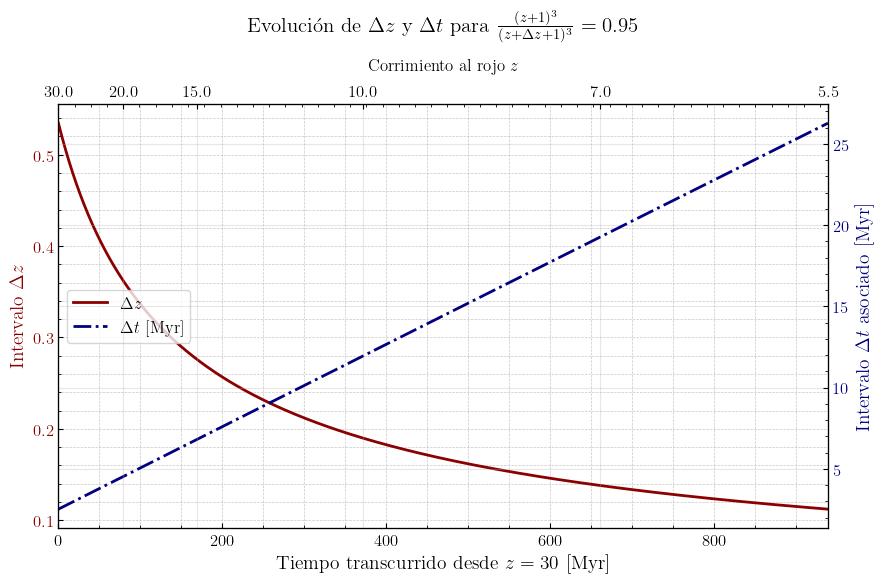

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18
import astropy.units as u

def calculate_delta_z(z: np.ndarray, target_ratio: float = 0.95) -> np.ndarray:
    """
    Calcula el intervalo delta_z tal que (z+1)^3 / (z+delta_z+1)^3 = target_ratio
    """
    factor = (1.0 / target_ratio)**(1.0/3.0) - 1.0
    return (z + 1.0) * factor

# Arreglo de z desde 30 hasta el presente local (z=5.5)
z_array = np.linspace(30, 5.5, 500)

# Cálculo analítico de Delta z
delta_z_array = calculate_delta_z(z_array)

# Edades del universo evaluadas en z, en z + Delta z, y el origen z=30
age_z = Planck18.age(z_array)
age_z_plus_delta = Planck18.age(z_array + delta_z_array)
age_z30 = Planck18.age(30)

# Eje X principal: Tiempo transcurrido desde z=30 (en Gyr)
time_elapsed = (age_z - age_z30).to(u.Myr).value

# Eje Y secundario: Intervalo de tiempo Delta t físico (en Myr)
# (La edad en z es mayor que en z + Delta z)
delta_t_myr = (age_z - age_z_plus_delta).to(u.Myr).value

# Configuración de la figura
fig, ax1 = plt.subplots(figsize=(9, 6))

# 1. Graficar Delta z en el eje Y izquierdo
color1 = 'darkred'
ax1.set_xlabel(r'Tiempo transcurrido desde $z=30$ [Myr]', fontsize=14)
ax1.set_ylabel(r'Intervalo $\Delta z$', fontsize=14, color=color1)
line1 = ax1.plot(time_elapsed, delta_z_array, color=color1, lw=2, label=r'$\Delta z$')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax1.set_xlim(0, max(time_elapsed))

# 2. Crear y graficar Delta t en el eje Y derecho
ax2 = ax1.twinx()
color2 = 'navy'
ax2.set_ylabel(r'Intervalo $\Delta t$ asociado [Myr]', fontsize=14, color=color2)
line2 = ax2.plot(time_elapsed, delta_t_myr, color=color2, lw=2, linestyle='-.', label=r'$\Delta t$ [Myr]')
ax2.tick_params(axis='y', labelcolor=color2)

# Unificar leyendas
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center left', fontsize=12)

# 3. Eje secundario superior para los valores de z de referencia
ax3 = ax1.twiny()
z_ticks = np.array([30, 20, 15, 10, 7,5.5])
# Interpolar para colocar los ticks de z correctamente en el eje de tiempo transcurrido
t_ticks = np.interp(z_ticks[::-1], z_array[::-1], time_elapsed[::-1])[::-1]

ax3.set_xlim(ax1.get_xlim())
ax3.set_xticks(t_ticks)
ax3.set_xticklabels([f'{z}' for z in z_ticks])
ax3.set_xlabel(r'Corrimiento al rojo $z$', fontsize=12, labelpad=10)

plt.title(r'Evolución de $\Delta z$ y $\Delta t$ para $\frac{(z+1)^3}{(z+\Delta z+1)^3} = 0.95$', 
          fontsize=15, pad=20)

fig.tight_layout()
plt.show()

In [7]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import root_scalar

# --- Physical Constants (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
ELECTRON_MASS_MKS = 9.1093837139e-31
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
ELECTRON_CHARGE_MKS = 1.602176634e-19 
T_CMB_0 = 2.7255

EV_MKS = ELECTRON_CHARGE_MKS
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2

def get_kinetic_energy_cutoff(z: float, min_simulation_energy_eV: float, losing_tolerance: float = 1e-2) -> float:
    """
    Evaluates param_values[6] (Kinetic energy cutoff) from the given C structure.
    Returns the cutoff energy in Joules.
    """
    
    # param_values[1]: Inverse of the expansion factor
    expansion_factor_inv = 1.0 + z
    
    # param_values[2]: Thermal energy
    cmb_energy_0 = BOLTZMANN_CONSTANT_MKS * T_CMB_0
    thermal_energy = cmb_energy_0 * expansion_factor_inv
    
    # Target area for the integration of the Planck distribution
    # Total integral of x^2/(e^x - 1) is 2 * Zeta(3) = 2.4041138
    max_area = 2.4041138 * (1.0 - losing_tolerance)
    
    # Planck integrand f(x) = x^2 / (exp(x) - 1)
    def planck_integrand(x):
        if x < 1e-8:
            return x  # Limit of x^2 / (x + x^2/2 + ...) as x->0
        return (x * x) / np.expm1(x)
        
    # Objective function for root finding to replace the C while-loop
    def objective(x_max):
        tot_area, _ = quad(planck_integrand, 0, x_max, limit=100)
        return tot_area - max_area
        
    # Find x where the cumulative integral reaches max_area
    # Bounded between a small number and 50.0 (the safety break in the C code)
    res = root_scalar(objective, bracket=[1e-5, 50.0], method='brentq')
    x_val = res.root
    
    # param_values[4]: MaxPhotonEnergy BB distribution
    max_photon_energy = x_val * thermal_energy
    
    print(f"X_max BB distribution = {x_val:e}")
    print(f"MaxPhotonEnergy BB distribution = {max_photon_energy / EV_MKS:e} eV")
    print(f"CMB energy (z={z:.6f}) = {thermal_energy:e} J")
    
    # param_values[6] logic
    min_sim_energy_J = min_simulation_energy_eV * EV_MKS
    
    ratio_rest = min_sim_energy_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot = min_sim_energy_J / max_photon_energy
    
    g = ratio_rest + np.sqrt((ratio_rest * ratio_rest) + ratio_phot)
    gamma_cut = (g * g + 1.0) / (2.0 * g)
    
    param_values_6 = ELECTRON_REST_ENERGY_MKS * (gamma_cut - 1.0)
    
    print(f"Kinetic energy cutoff = {param_values_6 / EV_MKS:e} eV")
    
    return param_values_6

# Example execution based on standard astrophysical initialization parameters:
if __name__ == "__main__":
    z_eval = 10.0
    min_energy_eval = 10.2  # eV
    tolerance = 0.01        # Equivalent to 1% LossingTolerance
    
    param_6_result = get_kinetic_energy_cutoff(z_eval, min_energy_eval, tolerance)

X_max BB distribution = 8.172308e+00
MaxPhotonEnergy BB distribution = 2.111331e-02 eV
CMB energy (z=10.000000) = 4.139253e-22 J
Kinetic energy cutoff = 5.116434e+06 eV


In [8]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import root_scalar

# --- Physical Constants (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
ELECTRON_MASS_MKS = 9.1093837139e-31
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
ELECTRON_CHARGE_MKS = 1.602176634e-19 
T_CMB_0 = 2.7255

EV_MKS = ELECTRON_CHARGE_MKS
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2

def get_kinetic_energy_thresholds(z: float, min_simulation_energy_eV: float, losing_tolerance: float = 1e-2, target_upscatter_eV: float = 1e3) -> dict:
    """
    Evaluates param_values[6] (Kinetic energy cutoff) from the given C structure, 
    and also computes the electron kinetic energy required so that 99% of the 
    scattered CMB photons reach at least `target_upscatter_eV`.
    """
    
    # param_values[1]: Inverse of the expansion factor
    expansion_factor_inv = 1.0 + z
    
    # param_values[2]: Thermal energy
    cmb_energy_0 = BOLTZMANN_CONSTANT_MKS * T_CMB_0
    thermal_energy = cmb_energy_0 * expansion_factor_inv
    
    # Total integral of x^2/(e^x - 1) is 2 * Zeta(3) = 2.4041138
    total_planck_area = 2.4041138
    
    # Planck integrand f(x) = x^2 / (exp(x) - 1)
    def planck_integrand(x):
        if x < 1e-8:
            return x  # Limit of x^2 / (x + x^2/2 + ...) as x->0
        return (x * x) / np.expm1(x)

    # -------------------------------------------------------------------------
    # 1. Original Calculation: Upper cutoff (capturing 1 - losing_tolerance of photons)
    # -------------------------------------------------------------------------
    max_area = total_planck_area * (1.0 - losing_tolerance)
    
    def objective_max(x_max):
        tot_area, _ = quad(planck_integrand, 0, x_max, limit=100)
        return tot_area - max_area
        
    res_max = root_scalar(objective_max, bracket=[1e-5, 50.0], method='brentq')
    x_max_val = res_max.root
    max_photon_energy = x_max_val * thermal_energy
    
    min_sim_energy_J = min_simulation_energy_eV * EV_MKS
    ratio_rest_max = min_sim_energy_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_max = min_sim_energy_J / max_photon_energy
    
    g_max = ratio_rest_max + np.sqrt((ratio_rest_max * ratio_rest_max) + ratio_phot_max)
    gamma_cut = (g_max * g_max + 1.0) / (2.0 * g_max)
    
    param_values_6 = ELECTRON_REST_ENERGY_MKS * (gamma_cut - 1.0)

    # -------------------------------------------------------------------------
    # 2. New Calculation: 99% of scattered photons >= target_upscatter_eV
    # -------------------------------------------------------------------------
    # To ensure 99% of CMB photons have enough initial energy to reach the target,
    # we must find the x_min where the bottom 1% of the photon distribution lies.
    # (Leaving 99% of the distribution above this energy).
    min_area = total_planck_area * 0.01 
    
    def objective_min(x_min):
        tot_area, _ = quad(planck_integrand, 0, x_min, limit=100)
        return tot_area - min_area
        
    res_min = root_scalar(objective_min, bracket=[1e-5, 10.0], method='brentq')
    x_min_val = res_min.root
    min_photon_energy_99 = x_min_val * thermal_energy
    
    target_upscatter_J = target_upscatter_eV * EV_MKS
    ratio_rest_min = target_upscatter_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_min = target_upscatter_J / min_photon_energy_99
    
    g_min = ratio_rest_min + np.sqrt((ratio_rest_min * ratio_rest_min) + ratio_phot_min)
    gamma_target = (g_min * g_min + 1.0) / (2.0 * g_min)
    
    ke_99_percent_scatter = ELECTRON_REST_ENERGY_MKS * (gamma_target - 1.0)

    # -------------------------------------------------------------------------
    # Terminal Output
    # -------------------------------------------------------------------------
    print(f"--- CMB Parameters (z={z:.6f}) ---")
    print(f"CMB thermal energy            = {thermal_energy:e} J")
    
    print("\n--- Original Cutoff (param_values[6]) ---")
    print(f"X_max BB distribution         = {x_max_val:e}")
    print(f"MaxPhotonEnergy BB dist       = {max_photon_energy / EV_MKS:e} eV")
    print(f"Kinetic energy cutoff         = {param_values_6 / EV_MKS:e} eV")

    print(f"\n--- 99% Upscatter Target (>= {target_upscatter_eV:.1e} eV) ---")
    print(f"X_min BB distribution (1%)    = {x_min_val:e}")
    print(f"MinPhotonEnergy (99% exceed)  = {min_photon_energy_99 / EV_MKS:e} eV")
    print(f"Required Electron KE          = {ke_99_percent_scatter / EV_MKS:e} eV\n")
    
    return {
        "param_values_6": param_values_6,
        "ke_99_percent_scatter": ke_99_percent_scatter
    }

# Example execution based on standard astrophysical initialization parameters:
if __name__ == "__main__":
    z_eval = 10.0
    min_energy_eval = 10.2       # eV
    tolerance = 0.01             # Equivalent to 1% LossingTolerance
    target_scatter_energy = 1e3  # eV
    
    results = get_kinetic_energy_thresholds(z_eval, min_energy_eval, tolerance, target_scatter_energy)

--- CMB Parameters (z=10.000000) ---
CMB thermal energy            = 4.139253e-22 J

--- Original Cutoff (param_values[6]) ---
X_max BB distribution         = 8.172308e+00
MaxPhotonEnergy BB dist       = 2.111331e-02 eV
Kinetic energy cutoff         = 5.116434e+06 eV

--- 99% Upscatter Target (>= 1.0e+03 eV) ---
X_min BB distribution (1%)    = 2.278436e-01
MinPhotonEnergy (99% exceed)  = 5.886382e-04 eV
Required Electron KE          = 3.325062e+08 eV



In [9]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.integrate import solve_ivp, quad, nquad
from scipy.special import genlaguerre, spherical_jn, roots_laguerre
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u
import warnings

warnings.filterwarnings("ignore", category=IntegrationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- 1. Publication-Quality Formatting ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 14,
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "lines.linewidth": 1.5
})

# --- 2. Physical Constants (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
YEAR_MKS = 3.15569251e7
VACUUM_PERMEABILITY_NORM = 1.00000000055
ELECTRON_MASS_MKS = 9.1093837139e-31
T_CMB_0 = 2.7255
U_CMB_0_J_M3 = 4.17e-14  

EV_MKS = ELECTRON_CHARGE_MKS
PLANCK_CONSTANT_REDUCED_MKS = PLANCK_CONSTANT_MKS / (2.0 * np.pi)
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS**2)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS**2 / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS**2 / (2.0 * VACUUM_PERMITTIVITY * PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS)
RY_ENERGY_MKS = FINE_STRUCTURE_CONSTANT**2 * ELECTRON_REST_ENERGY_MKS / 2.0
THOMSON_CROSS_SECTION_MKS = (8.0 * np.pi / 3.0) * ELECTRON_RADIUS_MKS**2
BOHR_RADIUS_MKS = PLANCK_CONSTANT_REDUCED_MKS / (ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * FINE_STRUCTURE_CONSTANT)

E0 = ELECTRON_REST_ENERGY_MKS

# --- Astrophysical Parameters ---
B0 = 1e-9 * 1e-4  
ION_FRACTION = 1e-4  
Z_target = 1.0 
delta_gould = 0.5 
threshold_eV_ion = RY_ENERGY_MKS / EV_MKS
threshold_eV_exc = 10.204

# Define a broad cosmological grid for interpolators
z_max_interp = 15.0
z_array_interp = np.logspace(-3, np.log10(z_max_interp), 10000)
z_array_interp = np.insert(z_array_interp, 0, 0.0)
t_array_interp = Planck18.age(z_array_interp).to(u.s).value

t_grid_sort = t_array_interp[::-1]
z_grid_sort = z_array_interp[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")
H_interp = interp1d(t_grid_sort, Planck18.H(z_grid_sort).to(u.s**-1).value, kind='cubic', fill_value="extrapolate")

# --- 3. Physics Pre-computations (Cross Sections & Kernels) ---
print("Pre-calculating kernels...")
def compute_F_KN(b_val):
    if b_val < 1e-4: return 1.0
    def integrand(q, x):
        if x < 1e-5: planck = x**2
        elif x > 100: return 0.0
        else: planck = x**3 / (np.exp(x) - 1.0)
        
        if q <= 0: return planck
        xb = x * b_val
        kernel = 2*q*np.log(q) + (1+2*q)*(1-q) + ((xb*q)**2 * (1-q))/(2*(1+xb*q))
        return planck * kernel / (1 + xb*q)**3
    res, _ = nquad(integrand, [[0, 1], [0, 100]], opts=[{'limit': 50}, {'limit': 50}])
    return res * 45.0 / (np.pi**4)

b_grid = np.logspace(-4, 4, 50)
F_KN_interp = interp1d(b_grid, np.array([compute_F_KN(b) for b in b_grid]), kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

_laguerre_x, _laguerre_w = roots_laguerre(70)
def calculate_sigma_hydrogen_universal(T, n):
    if T <= 10.204: return 0.0
    a0, R, mc2 = BOHR_RADIUS_MKS * 1e10, RY_ENERGY_MKS / EV_MKS, ELECTRON_REST_ENERGY_MKS / EV_MKS
    params = {2: [10.204, 0.4164, 0.555512, 0.271785, 0.000112], 3: [12.094, 0.0791, 0.089083, 0.060202,-0.019775]}
    if n not in params: return 0.0 
    E, f0, a_bethe, b_bethe, c_bethe = params[n]
    if T < 3000:
        q_min, q_max = (np.sqrt(T) - np.sqrt(T - E))**2 / R, (np.sqrt(T) + np.sqrt(T - E))**2 / R
        def exact_gos(Q):
            q, norm = np.sqrt(max(Q, 1e-12)), np.sqrt((2.0/n)**3 * math.factorial(n-2) / (2*n*math.factorial(n+1)))
            r = _laguerre_x / (1.0 + 1.0/n)
            poly_part = 2.0 * norm * (2.0*r/n) * genlaguerre(n-2, 3)(2.0*r/n) * spherical_jn(1, q*r) * (r**2) * np.sqrt(3)
            return ((1.0 - 1.0/(n**2)) / max(Q, 1e-12)) * (np.sum(_laguerre_w * poly_part) / (1.0 + 1.0/n))**2
        f_pwb_val, _ = quad(lambda Q: exact_gos(Q) / (E/R) / Q, q_min, q_max, limit=200)
        return (4 * np.pi * a0**2 * R / T) * f_pwb_val * (T / (T + R + E))
    elif T < 1e5:
        return ((4 * np.pi * a0**2 * R) / (T + R + E)) * (a_bethe * np.log(T / R) + b_bethe + (c_bethe * R / T))
    else:
        gamma, beta2 = 1 + (T / mc2), 1.0 - 1.0 / ((1 + (T / mc2))**2)
        return ((8 * np.pi * a0**2 / beta2) * (R / mc2)) * (a_bethe * (np.log(gamma**2 - 1.0) - beta2) + b_bethe - a_bethe * np.log(2 * R / mc2))

K_e_grid_eval = np.logspace(np.log10(10.204), 14, 500) 
loss_array_exc = np.array([sum(calculate_sigma_hydrogen_universal(K_e, n) * 1e-20 * E for n, E in zip([2,3], [10.204, 12.094]) if K_e > E) for K_e in K_e_grid_eval])
loss_interp_exc = interp1d(K_e_grid_eval, loss_array_exc, kind='linear', fill_value=0.0, bounds_error=False)

DipoleFit = [-0.0224728, 1.177455, -0.4626461, 0.08906479] 
DipoleIntegralFit = np.array([df / (j + 2) for j, df in enumerate(DipoleFit)])
DipoleIntegralSum, DipoleStrength = np.sum(DipoleIntegralFit), 2.0 - np.sum([df / (j + 1) for j, df in enumerate(DipoleFit)])
def coll_ionisation_cross_section(K):
    if K <= RY_ENERGY_MKS: return 0.0
    k, k_b, b, e = K / E0, K / RY_ENERGY_MKS, RY_ENERGY_MKS / E0, 1.0 + K / E0
    v2, bv2 = 1.0 - 1.0 / (e**2), 1.0 - 1.0 / ((1.0 + b)**2)
    integral = DipoleIntegralFit[-1]
    for i in range(2, -1, -1): integral = integral * (2.0 / (k_b + 1.0)) + DipoleIntegralFit[i]
    t1 = (np.log(0.5 * k_b * (e + 1.0)) - v2) * (DipoleIntegralSum - integral * (2.0 / (k_b + 1.0))**2)
    t2 = ((0.5 * (k_b - 1.0) * b**2 - np.log(k_b) * (e + k) / (1.0 + k_b)) / (1.0 + 0.5 * k)**2 + 1.0 - 1.0 / k_b) * DipoleStrength
    return (2.0 * np.pi * ELECTRON_RADIUS_MKS**2 / (b * (v2 + 2 * bv2))) * (t1 + t2)

loss_array_ion = []
for K_e in K_e_grid_eval:
    if K_e <= threshold_eV_ion: loss_array_ion.append(0.0)
    else:
        eps_max = (K_e - threshold_eV_ion) / 2.0
        n_int, _ = quad(lambda eps: 1.0 / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        e_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        loss_array_ion.append(coll_ionisation_cross_section(K_e * EV_MKS) * (threshold_eV_ion + (e_int/n_int if n_int>0 else 0.0)))
loss_interp_ion = interp1d(K_e_grid_eval, np.array(loss_array_ion), kind='linear', fill_value=0.0, bounds_error=False)

# --- 4. Scalar ODE Evaluator with Toggles ---
cooling_toggles_custom = {
    'adiabatic': True,
    'synchrotron': True,
    'compton': True,
    'coulomb': True,
    'excitation': True,
    'ionization': True
}
cooling_toggles_baseline = {k: True for k in cooling_toggles_custom}

def get_cooling_rate_evaluator(toggles):
    def evaluator(t, K):
        K_val = K[0]
        if K_val <= 0: return [0.0]
        
        E_val = K_val + E0
        gamma = E_val / E0
        z = float(z_interp(t))
        
        p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
        v = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
        n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
        
        L_ad = 0.0
        if toggles['adiabatic']:
            L_ad = float(H_interp(t)) * p_sqrd_c_sqrd / E_val
            
        L_synch = 0.0
        if toggles['synchrotron']:
            U_B = ((B0 * (1 + z)**2)**2) / (2 * VACUUM_PERMEABILITY)
            L_synch = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p_sqrd_c_sqrd
            
        L_ic = 0.0
        if toggles['compton']:
            T_CMB_z, U_CMB_z = T_CMB_0 * (1.0 + z), U_CMB_0_J_M3 * (1 + z)**4
            L_ic = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z / E0**2) * p_sqrd_c_sqrd * float(F_KN_interp(4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0))
        
        L_coulomb = 0.0
        if toggles['coulomb']:
            n_e = ION_FRACTION * n_HI_z
            x = np.sqrt(K_val / E0) * v * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * np.sqrt(n_e * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS)))
            if x > 0:
                fb = math.log(x) + math.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
                L_coulomb = (n_e * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * fb / (4.0 * math.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * v**2)) * v

        K_eV = K_val / EV_MKS
        
        L_exc = 0.0
        if toggles['excitation'] and K_eV >= threshold_eV_exc:
            L_exc = max(0.0, (n_HI_z * v * float(loss_interp_exc(K_eV))) * EV_MKS)            
        L_ion = 0.0
        if toggles['ionization'] and K_eV >= threshold_eV_ion:
            L_ion = max(0.0, (n_HI_z * v * float(loss_interp_ion(K_eV))) * EV_MKS)
        return [-(L_ad + L_synch + L_ic + L_coulomb + L_exc + L_ion)]
        
    return evaluator

def thermalization_limit(t, K):
    return K[0] - (BOLTZMANN_CONSTANT_MKS * T_CMB_0 * (1.0 + z_interp(t)))
thermalization_limit.terminal = True
thermalization_limit.direction = -1

# #--- 5. Plotting Trajectories and Gradient Mechanisms ---
# print("Integrating individual trajectories...")

# fig, axes = plt.subplots(2, 1, figsize=(10.0, 14.0), sharex=True)

# def draw_phase_panel(ax, toggles, title):
#     active_evaluator = get_cooling_rate_evaluator(toggles)
    
#     initial_energies_eV = [1e12, 1e4]
#     initial_redshifts = [10.0, 9.0, 8.0, 7.0, 6.0]
#     z_end_plot = 2.0 
    
#     # Map colors to initial redshift explicitly
#     z_colors = {
#         10.0: '#1f77b4', 
#         9.0: '#ff7f0e', 
#         8.0: '#2ca02c', 
#         7.0: '#d62728',
#         6.0: '#9467bd'
#     }
    
#     for z_start in initial_redshifts:
#         t_start = Planck18.age(z_start).to(u.s).value
#         t_end = Planck18.age(z_end_plot).to(u.s).value
        
#         t_eval = np.logspace(np.log10(t_start), np.log10(t_end), 5000)
        
#         for K_ini_eV in initial_energies_eV:
#             K_ini_J = K_ini_eV * EV_MKS
            
#             sol = solve_ivp(active_evaluator, 
#                             t_span=(t_eval[0], t_eval[-1]), 
#                             y0=[K_ini_J], 
#                             events=thermalization_limit,
#                             dense_output=True,
#                             method='Radau', 
#                             rtol=1e-6, atol=1e-25)
            
#             active_mask = t_eval <= sol.t[-1]
#             t_active = t_eval[active_mask]
#             K_active_eV = sol.sol(t_active)[0] / EV_MKS
#             z_active = z_interp(t_active)
            
#             # Plot the continuous trajectory matching the redshift color
#             ax.plot(z_active, K_active_eV, color=z_colors[z_start], lw=1.5)
            
#             # Flag placement to mark the initial energy only on the highest redshift (for visual clarity)
#             if z_start == initial_redshifts[0]:
#                 exp_val = int(np.log10(K_ini_eV))
#                 ax.text(z_start + 0.1, K_ini_eV, rf'$10^{{{exp_val}}}$ eV', fontsize=11, va='center', ha='right', color='black')

#     # Formatting 
#     ax.set_yscale('log')
#     ax.set_xlim(max(initial_redshifts) + 0.8, z_end_plot) 
#     ax.set_ylim(1e0, 3e13)
#     ax.set_title(title, fontsize=15, pad=15)
#     ax.set_ylabel(r'Energía cinética $K_{\mathrm{e}}$ [eV]', fontsize=14)
    
#     # Red dashed references
#     line_ref1, = ax.plot(z_array_interp, 5.11e6*((1+z_array_interp)/(1+10.0))**2, color='red', linestyle=':', alpha=0.8, label=r'Fotoionización sec. ($z_{ref}=10$)')
#     line_ref2, = ax.plot(z_array_interp, 5e8*((1+z_array_interp)/(1+10.0))**2, color='red', linestyle=':', alpha=0.8)
#     line_zref = ax.axvline(5.5, color='red', linestyle='--', alpha=0.5, label=r'$z_{ref}=5.5$')
#     ax.grid(True, which="major", ls="-", alpha=0.3, color='grey')
    
#     # Constructing Custom Legend mapping LineColors to Redshift Values
#     legend_elements = [mlines.Line2D([0], [0], color=c, lw=2, label=rf'$z_i = {z}$') for z, c in z_colors.items()]
#     legend_elements.extend([line_ref1, line_zref])
    
#     ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', ncol=2)

# # Build Top Panel
# draw_phase_panel(axes[0], cooling_toggles_baseline, "Todos los mecanismos de pérdida activos")

# # Build Bottom Panel
# mechanism_names = ['Exp. Adiabática', 'Sincrotrón', 'Compton', 'Coulomb (Plasma)', 'Excitación Colisional', 'Ionización Colisional']
# mechanism_keys = ['adiabatic', 'synchrotron', 'compton', 'coulomb', 'excitation', 'ionization']
# title_disabled = ', '.join([name for key, name in zip(mechanism_keys, mechanism_names) if not cooling_toggles_custom[key]])
# draw_phase_panel(axes[1], cooling_toggles_custom, f"Sin considerar: {title_disabled}" if title_disabled else "Todos los mecanismos activos")

# axes[1].set_xlabel(r'Redshift $z$', fontsize=14)

# plt.tight_layout()
# plt.savefig(f'electron_cooling_by_redshift.png', dpi=300, bbox_inches='tight')
# plt.show()

Pre-calculating kernels...


In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.integrate import solve_ivp, quad, nquad
from scipy.special import genlaguerre, spherical_jn, roots_laguerre
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from astropy.cosmology import Planck18
import astropy.units as u
import warnings

warnings.filterwarnings("ignore", category=IntegrationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- 1. Publication-Quality Formatting ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 14,
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "lines.linewidth": 1.5
})

# --- 2. Physical Constants (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
YEAR_MKS = 3.15569251e7
VACUUM_PERMEABILITY_NORM = 1.00000000055
ELECTRON_MASS_MKS = 9.1093837139e-31
T_CMB_0 = 2.7255
U_CMB_0_J_M3 = 4.17e-14  

EV_MKS = ELECTRON_CHARGE_MKS
PLANCK_CONSTANT_REDUCED_MKS = PLANCK_CONSTANT_MKS / (2.0 * np.pi)
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS**2)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS**2 / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS**2 / (2.0 * VACUUM_PERMITTIVITY * PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS)
RY_ENERGY_MKS = FINE_STRUCTURE_CONSTANT**2 * ELECTRON_REST_ENERGY_MKS / 2.0
THOMSON_CROSS_SECTION_MKS = (8.0 * np.pi / 3.0) * ELECTRON_RADIUS_MKS**2
BOHR_RADIUS_MKS = PLANCK_CONSTANT_REDUCED_MKS / (ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * FINE_STRUCTURE_CONSTANT)

E0 = ELECTRON_REST_ENERGY_MKS

# --- Astrophysical Parameters ---
B0 = 1e-9 * 1e-4  
ION_FRACTION = 1e-4  
Z_target = 1.0 
delta_gould = 0.5 
threshold_eV_ion = RY_ENERGY_MKS / EV_MKS
threshold_eV_exc = 10.204

# Define a broad cosmological grid for interpolators
z_max_interp = 35.0
z_array_interp = np.logspace(-3, np.log10(z_max_interp), 10000)
z_array_interp = np.insert(z_array_interp, 0, 0.0)
t_array_interp = Planck18.age(z_array_interp).to(u.s).value

t_grid_sort = t_array_interp[::-1]
z_grid_sort = z_array_interp[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")
H_interp = interp1d(t_grid_sort, Planck18.H(z_grid_sort).to(u.s**-1).value, kind='cubic', fill_value="extrapolate")

# --- 3. Physics Pre-computations (Cross Sections & Kernels) ---
print("Pre-calculating kernels...")
def compute_F_KN(b_val):
    if b_val < 1e-4: return 1.0
    def integrand(q, x):
        if x < 1e-5: planck = x**2
        elif x > 100: return 0.0
        else: planck = x**3 / (np.exp(x) - 1.0)
        
        if q <= 0: return planck
        xb = x * b_val
        kernel = 2*q*np.log(q) + (1+2*q)*(1-q) + ((xb*q)**2 * (1-q))/(2*(1+xb*q))
        return planck * kernel / (1 + xb*q)**3
    res, _ = nquad(integrand, [[0, 1], [0, 100]], opts=[{'limit': 50}, {'limit': 50}])
    return res * 45.0 / (np.pi**4)

b_grid = np.logspace(-4, 4, 50)
F_KN_interp = interp1d(b_grid, np.array([compute_F_KN(b) for b in b_grid]), kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

_laguerre_x, _laguerre_w = roots_laguerre(70)
def calculate_sigma_hydrogen_universal(T, n):
    if T <= 10.204: return 0.0
    a0, R, mc2 = BOHR_RADIUS_MKS * 1e10, RY_ENERGY_MKS / EV_MKS, ELECTRON_REST_ENERGY_MKS / EV_MKS
    params = {2: [10.204, 0.4164, 0.555512, 0.271785, 0.000112], 3: [12.094, 0.0791, 0.089083, 0.060202,-0.019775]}
    if n not in params: return 0.0 
    E, f0, a_bethe, b_bethe, c_bethe = params[n]
    if T < 3000:
        q_min, q_max = (np.sqrt(T) - np.sqrt(T - E))**2 / R, (np.sqrt(T) + np.sqrt(T - E))**2 / R
        def exact_gos(Q):
            q, norm = np.sqrt(max(Q, 1e-12)), np.sqrt((2.0/n)**3 * math.factorial(n-2) / (2*n*math.factorial(n+1)))
            r = _laguerre_x / (1.0 + 1.0/n)
            poly_part = 2.0 * norm * (2.0*r/n) * genlaguerre(n-2, 3)(2.0*r/n) * spherical_jn(1, q*r) * (r**2) * np.sqrt(3)
            return ((1.0 - 1.0/(n**2)) / max(Q, 1e-12)) * (np.sum(_laguerre_w * poly_part) / (1.0 + 1.0/n))**2
        f_pwb_val, _ = quad(lambda Q: exact_gos(Q) / (E/R) / Q, q_min, q_max, limit=200)
        return (4 * np.pi * a0**2 * R / T) * f_pwb_val * (T / (T + R + E))
    elif T < 1e5:
        return ((4 * np.pi * a0**2 * R) / (T + R + E)) * (a_bethe * np.log(T / R) + b_bethe + (c_bethe * R / T))
    else:
        gamma, beta2 = 1 + (T / mc2), 1.0 - 1.0 / ((1 + (T / mc2))**2)
        return ((8 * np.pi * a0**2 / beta2) * (R / mc2)) * (a_bethe * (np.log(gamma**2 - 1.0) - beta2) + b_bethe - a_bethe * np.log(2 * R / mc2))

K_e_grid_eval = np.logspace(np.log10(10.204), 14, 500) 
loss_array_exc = np.array([sum(calculate_sigma_hydrogen_universal(K_e, n) * 1e-20 * E for n, E in zip([2,3], [10.204, 12.094]) if K_e > E) for K_e in K_e_grid_eval])
loss_interp_exc = interp1d(K_e_grid_eval, loss_array_exc, kind='linear', fill_value=0.0, bounds_error=False)

DipoleFit = [-0.0224728, 1.177455, -0.4626461, 0.08906479] 
DipoleIntegralFit = np.array([df / (j + 2) for j, df in enumerate(DipoleFit)])
DipoleIntegralSum, DipoleStrength = np.sum(DipoleIntegralFit), 2.0 - np.sum([df / (j + 1) for j, df in enumerate(DipoleFit)])
def coll_ionisation_cross_section(K):
    if K <= RY_ENERGY_MKS: return 0.0
    k, k_b, b, e = K / E0, K / RY_ENERGY_MKS, RY_ENERGY_MKS / E0, 1.0 + K / E0
    v2, bv2 = 1.0 - 1.0 / (e**2), 1.0 - 1.0 / ((1.0 + b)**2)
    integral = DipoleIntegralFit[-1]
    for i in range(2, -1, -1): integral = integral * (2.0 / (k_b + 1.0)) + DipoleIntegralFit[i]
    t1 = (np.log(0.5 * k_b * (e + 1.0)) - v2) * (DipoleIntegralSum - integral * (2.0 / (k_b + 1.0))**2)
    t2 = ((0.5 * (k_b - 1.0) * b**2 - np.log(k_b) * (e + k) / (1.0 + k_b)) / (1.0 + 0.5 * k)**2 + 1.0 - 1.0 / k_b) * DipoleStrength
    return (2.0 * np.pi * ELECTRON_RADIUS_MKS**2 / (b * (v2 + 2 * bv2))) * (t1 + t2)

loss_array_ion = []
for K_e in K_e_grid_eval:
    if K_e <= threshold_eV_ion: 
        loss_array_ion.append(0.0)
    else:
        eps_max = (K_e - threshold_eV_ion) / 2.0
        u_max = np.log(eps_max / 8.0)
        
        # Logarithmic substitution: eps = 8 * exp(u)
        def n_integrand_log(u):
            return 8.0 * np.exp(u) / (1.0 + np.exp(2.1 * u))
            
        def e_integrand_log(u):
            return 64.0 * np.exp(2.0 * u) / (1.0 + np.exp(2.1 * u))
            
        n_int, _ = quad(n_integrand_log, -np.inf, u_max, limit=100)
        e_int, _ = quad(e_integrand_log, -np.inf, u_max, limit=100)
        
        loss_array_ion.append(coll_ionisation_cross_section(K_e * EV_MKS) * (threshold_eV_ion + (e_int/n_int if n_int>0 else 0.0)))

loss_interp_ion = interp1d(K_e_grid_eval, np.array(loss_array_ion), kind='linear', fill_value=(0.0, loss_array_ion[-1]), bounds_error=False)
# def coll_ionisation_cross_section(K):
#     if K <= RY_ENERGY_MKS: return 0.0
#     k, k_b, b, e = K / E0, K / RY_ENERGY_MKS, RY_ENERGY_MKS / E0, 1.0 + K / E0
#     v2, bv2 = 1.0 - 1.0 / (e**2), 1.0 - 1.0 / ((1.0 + b)**2)
#     integral = DipoleIntegralFit[-1]
#     for i in range(2, -1, -1): integral = integral * (2.0 / (k_b + 1.0)) + DipoleIntegralFit[i]
#     t1 = (np.log(0.5 * k_b * (e + 1.0)) - v2) * (DipoleIntegralSum - integral * (2.0 / (k_b + 1.0))**2)
#     t2 = ((0.5 * (k_b - 1.0) * b**2 - np.log(k_b) * (e + k) / (1.0 + k_b)) / (1.0 + 0.5 * k)**2 + 1.0 - 1.0 / k_b) * DipoleStrength
#     return (2.0 * np.pi * ELECTRON_RADIUS_MKS**2 / (b * (v2 + 2 * bv2))) * (t1 + t2)

# loss_array_ion = []
# for K_e in K_e_grid_eval:
#     if K_e <= threshold_eV_ion: loss_array_ion.append(0.0)
#     else:
#         eps_max = (K_e - threshold_eV_ion) / 2.0
#         n_int, _ = quad(lambda eps: 1.0 / (1.0 + (eps/8.0)**2.1), 0, eps_max)
#         e_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max)
#         loss_array_ion.append(coll_ionisation_cross_section(K_e * EV_MKS) * (threshold_eV_ion + (e_int/n_int if n_int>0 else 0.0)))
# loss_interp_ion = interp1d(K_e_grid_eval, np.array(loss_array_ion), kind='linear', fill_value=0.0, bounds_error=False)

# --- 4. Kinematic Threshold Vectorization ---
print("Pre-calculating kinematic thresholds...")
def compute_threshold_curves(z_array, min_sim_eV=10.2, target_upscatter_eV=1e3, losing_tolerance=1e-2):
    total_planck_area = 2.4041138
    
    def planck_integrand(x):
        if x < 1e-8: return x
        return (x * x) / np.expm1(x)
        
    # 1. Roots are constant and scale-independent
    max_area = total_planck_area * (1.0 - losing_tolerance)
    res_max = root_scalar(lambda x: quad(planck_integrand, 0, x)[0] - max_area, bracket=[1e-5, 50.0])
    x_max_val = res_max.root
    
    min_area = total_planck_area * 0.01
    res_min = root_scalar(lambda x: quad(planck_integrand, 0, x)[0] - min_area, bracket=[1e-5, 10.0])
    x_min_val = res_min.root
    
    # 2. Vectorized evaluation for array of z
    cmb_energy_0 = BOLTZMANN_CONSTANT_MKS * T_CMB_0
    thermal_energy = cmb_energy_0 * (1.0 + z_array)
    
    max_photon_energy = x_max_val * thermal_energy
    min_photon_energy_99 = x_min_val * thermal_energy
    
    # param_values_6 calculation
    min_sim_J = min_sim_eV * EV_MKS
    ratio_rest_max = min_sim_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_max = min_sim_J / max_photon_energy
    g_max = ratio_rest_max + np.sqrt(ratio_rest_max**2 + ratio_phot_max)
    gamma_cut = (g_max**2 + 1.0) / (2.0 * g_max)
    ke_cutoff_array = ELECTRON_REST_ENERGY_MKS * (gamma_cut - 1.0) / EV_MKS
    
    # ke_99_percent_scatter calculation
    target_J = target_upscatter_eV * EV_MKS
    ratio_rest_min = target_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_min = target_J / min_photon_energy_99
    g_min = ratio_rest_min + np.sqrt(ratio_rest_min**2 + ratio_phot_min)
    gamma_target = (g_min**2 + 1.0) / (2.0 * g_min)
    ke_99_array = ELECTRON_REST_ENERGY_MKS * (gamma_target - 1.0) / EV_MKS
    
    return ke_cutoff_array, ke_99_array

# Compute thresholds for the global interpolation grid
ke_cutoff_array, ke_99_array = compute_threshold_curves(z_array_interp)



Pre-calculating kernels...
Pre-calculating kinematic thresholds...


Integrating individual trajectories...


/tmp/ipykernel_5580/327059143.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', ncol=2)


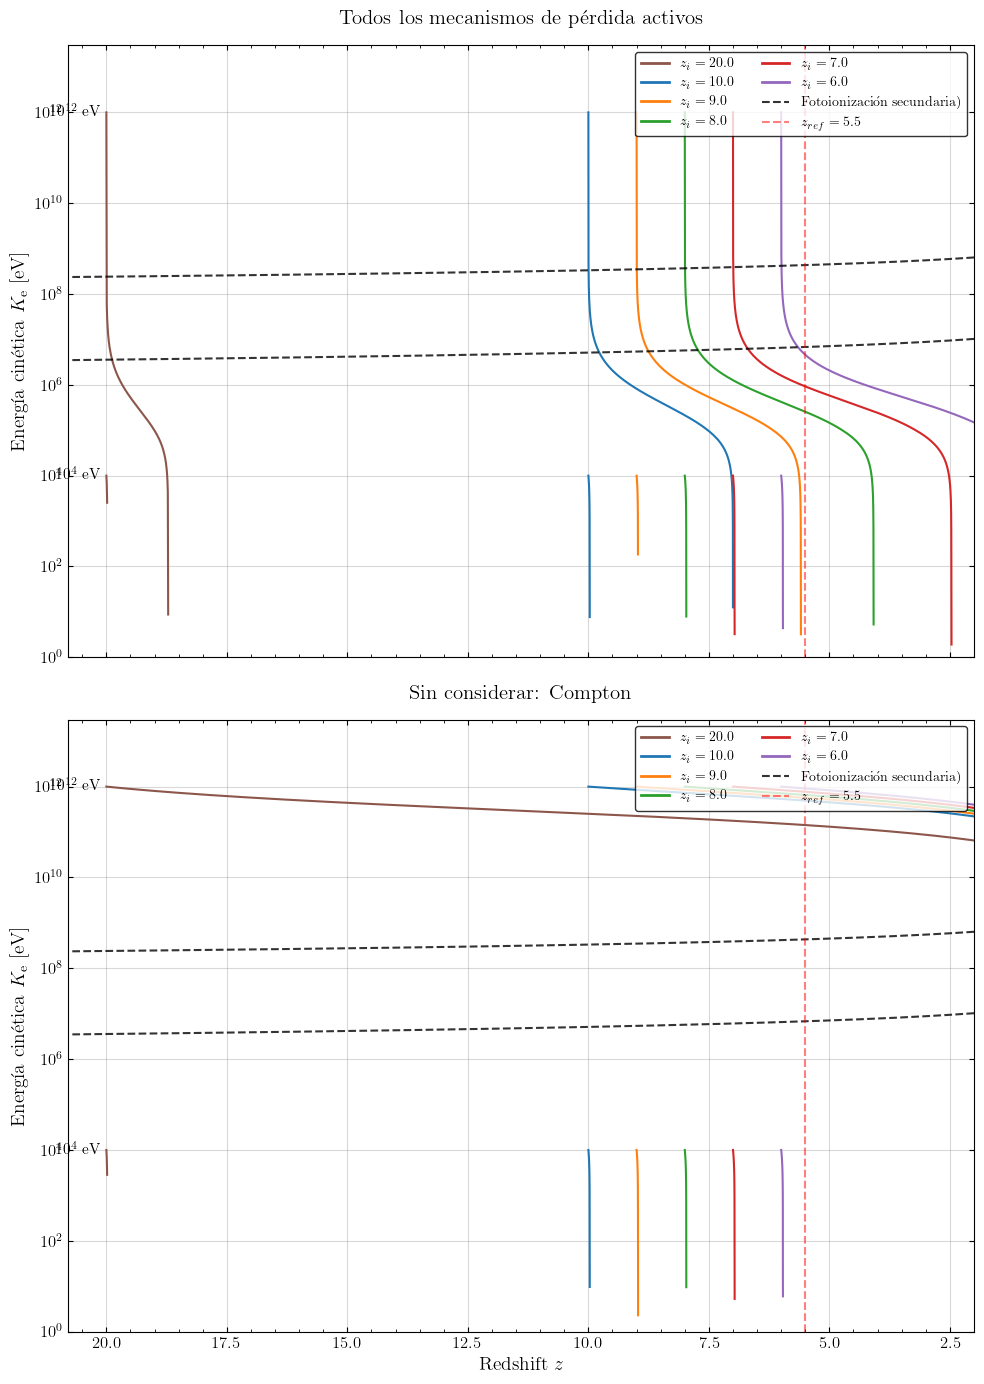

In [15]:

# --- 5. Scalar ODE Evaluator with Toggles ---
cooling_toggles_custom = {
    'adiabatic': True,
    'synchrotron': True,
    'compton': False,
    'coulomb': True,
    'excitation': True,
    'ionization': True
}
cooling_toggles_baseline = {k: True for k in cooling_toggles_custom}

def get_cooling_rate_evaluator(toggles):
    def evaluator(t, K):
        K_val = K[0]
        if K_val <= 0: return [0.0]
        
        E_val = K_val + E0
        gamma = E_val / E0
        z = float(z_interp(t))
        
        p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
        v = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
        n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
        
        L_ad = 0.0
        if toggles['adiabatic']:
            L_ad = float(H_interp(t)) * p_sqrd_c_sqrd / E_val
            
        L_synch = 0.0
        if toggles['synchrotron']:
            U_B = ((B0 * (1 + z)**2)**2) / (2 * VACUUM_PERMEABILITY)
            L_synch = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p_sqrd_c_sqrd
            
        L_ic = 0.0
        if toggles['compton']:
            T_CMB_z, U_CMB_z = T_CMB_0 * (1.0 + z), U_CMB_0_J_M3 * (1 + z)**4
            L_ic = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z / E0**2) * p_sqrd_c_sqrd * float(F_KN_interp(4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0))
        
        L_coulomb = 0.0
        if toggles['coulomb']:
            n_e = ION_FRACTION * n_HI_z
            x = np.sqrt(K_val / E0) * v * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * np.sqrt(n_e * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS)))
            if x > 0:
                fb = math.log(x) + math.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
                L_coulomb = (n_e * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * fb / (4.0 * math.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * v**2)) * v

        K_eV = K_val / EV_MKS
        
        L_exc = 0.0
        if toggles['excitation'] and K_eV >= threshold_eV_exc:
            L_exc = max(0.0, (n_HI_z * v * float(loss_interp_exc(K_eV))) * EV_MKS)            
        L_ion = 0.0
        if toggles['ionization'] and K_eV >= threshold_eV_ion:
            L_ion = max(0.0, (n_HI_z * v * float(loss_interp_ion(K_eV))) * EV_MKS)
        return [-(L_ad + L_synch + L_ic + L_coulomb + L_exc + L_ion)]
        
    return evaluator

def thermalization_limit(t, K):
    return K[0] - (BOLTZMANN_CONSTANT_MKS * T_CMB_0 * (1.0 + z_interp(t)))
thermalization_limit.terminal = True
thermalization_limit.direction = -1

#--- 6. Plotting Trajectories and Gradient Mechanisms ---
print("Integrating individual trajectories...")

fig, axes = plt.subplots(2, 1, figsize=(10.0, 14.0), sharex=True)

def draw_phase_panel(ax, toggles, title):
    active_evaluator = get_cooling_rate_evaluator(toggles)
    
    initial_energies_eV = [1e12, 1e4]
    initial_redshifts = [ 20.0, 10.0, 9.0, 8.0, 7.0, 6.0] #30.0,
    z_end_plot = 2.0 
    
    # Map colors to initial redshift explicitly
    z_colors = {
        #30.0: '#1f77b4',
        20.0: '#8c564b',
        10.0: '#1f77b4', 
        9.0: '#ff7f0e', 
        8.0: '#2ca02c', 
        7.0: '#d62728',
        6.0: '#9467bd'
    }
    
    for z_start in initial_redshifts:
        t_start = Planck18.age(z_start).to(u.s).value
        t_end = Planck18.age(z_end_plot).to(u.s).value
        
        t_eval = np.logspace(np.log10(t_start), np.log10(t_end), 5000)
        
        for K_ini_eV in initial_energies_eV:
            K_ini_J = K_ini_eV * EV_MKS
            
            sol = solve_ivp(active_evaluator, 
                            t_span=(t_eval[0], t_eval[-1]), 
                            y0=[K_ini_J], 
                            events=thermalization_limit,
                            dense_output=True,
                            method='Radau', 
                            rtol=1e-6, atol=1e-25)
            
            active_mask = t_eval <= sol.t[-1]
            t_active = t_eval[active_mask]
            K_active_eV = sol.sol(t_active)[0] / EV_MKS
            z_active = z_interp(t_active)
            
            # Plot the continuous trajectory matching the redshift color
            ax.plot(z_active, K_active_eV, color=z_colors[z_start], lw=1.5)
            
            # Flag placement to mark the initial energy only on the highest redshift (for visual clarity)
            if z_start == initial_redshifts[0]:
                exp_val = int(np.log10(K_ini_eV))
                ax.text(z_start + 0.1, K_ini_eV, rf'$10^{{{exp_val}}}$ eV', fontsize=11, va='center', ha='right', color='black')

    # Formatting 
    ax.set_yscale('log')
    ax.set_xlim(max(initial_redshifts) + 0.8, z_end_plot) 
    ax.set_ylim(1e0, 3e13)
    ax.set_title(title, fontsize=15, pad=15)
    ax.set_ylabel(r'Energía cinética $K_{\mathrm{e}}$ [eV]', fontsize=14)
    
    # Plot calculated kinematic curves
    line_cutoff, = ax.plot(z_array_interp, ke_cutoff_array, color='black', linestyle='--', alpha=0.8, label=r'Fotoionización secundaria)')
    line_99, = ax.plot(z_array_interp, ke_99_array, color='black', linestyle='--', alpha=0.8, )
    
    # Red dashed references
    
    line_zref = ax.axvline(5.5, color='red', linestyle='--', alpha=0.5, label=r'$z_{ref}=5.5$')
    
    ax.grid(True, which="major", ls="-", alpha=0.3, color='grey')
    
    # Constructing Custom Legend mapping LineColors to Redshift Values
    legend_elements = [mlines.Line2D([0], [0], color=c, lw=2, label=rf'$z_i = {z}$') for z, c in z_colors.items()]
    legend_elements.extend([line_cutoff, line_99, line_zref])
    
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', ncol=2)

# Build Top Panel
draw_phase_panel(axes[0], cooling_toggles_baseline, "Todos los mecanismos de pérdida activos")

# Build Bottom Panel
mechanism_names = ['Exp. Adiabática', 'Sincrotrón', 'Compton', 'Coulomb (Plasma)', 'Excitación Colisional', 'Ionización Colisional']
mechanism_keys = ['adiabatic', 'synchrotron', 'compton', 'coulomb', 'excitation', 'ionization']
title_disabled = ', '.join([name for key, name in zip(mechanism_keys, mechanism_names) if not cooling_toggles_custom[key]])
draw_phase_panel(axes[1], cooling_toggles_custom, f"Sin considerar: {title_disabled}" if title_disabled else "Todos los mecanismos activos")

axes[1].set_xlabel(r'Redshift $z$', fontsize=14)

plt.tight_layout()
plt.savefig(f'electron_cooling_by_redshift.png', dpi=300, bbox_inches='tight')
plt.show()

Integrating individual trajectories...


KeyboardInterrupt: 

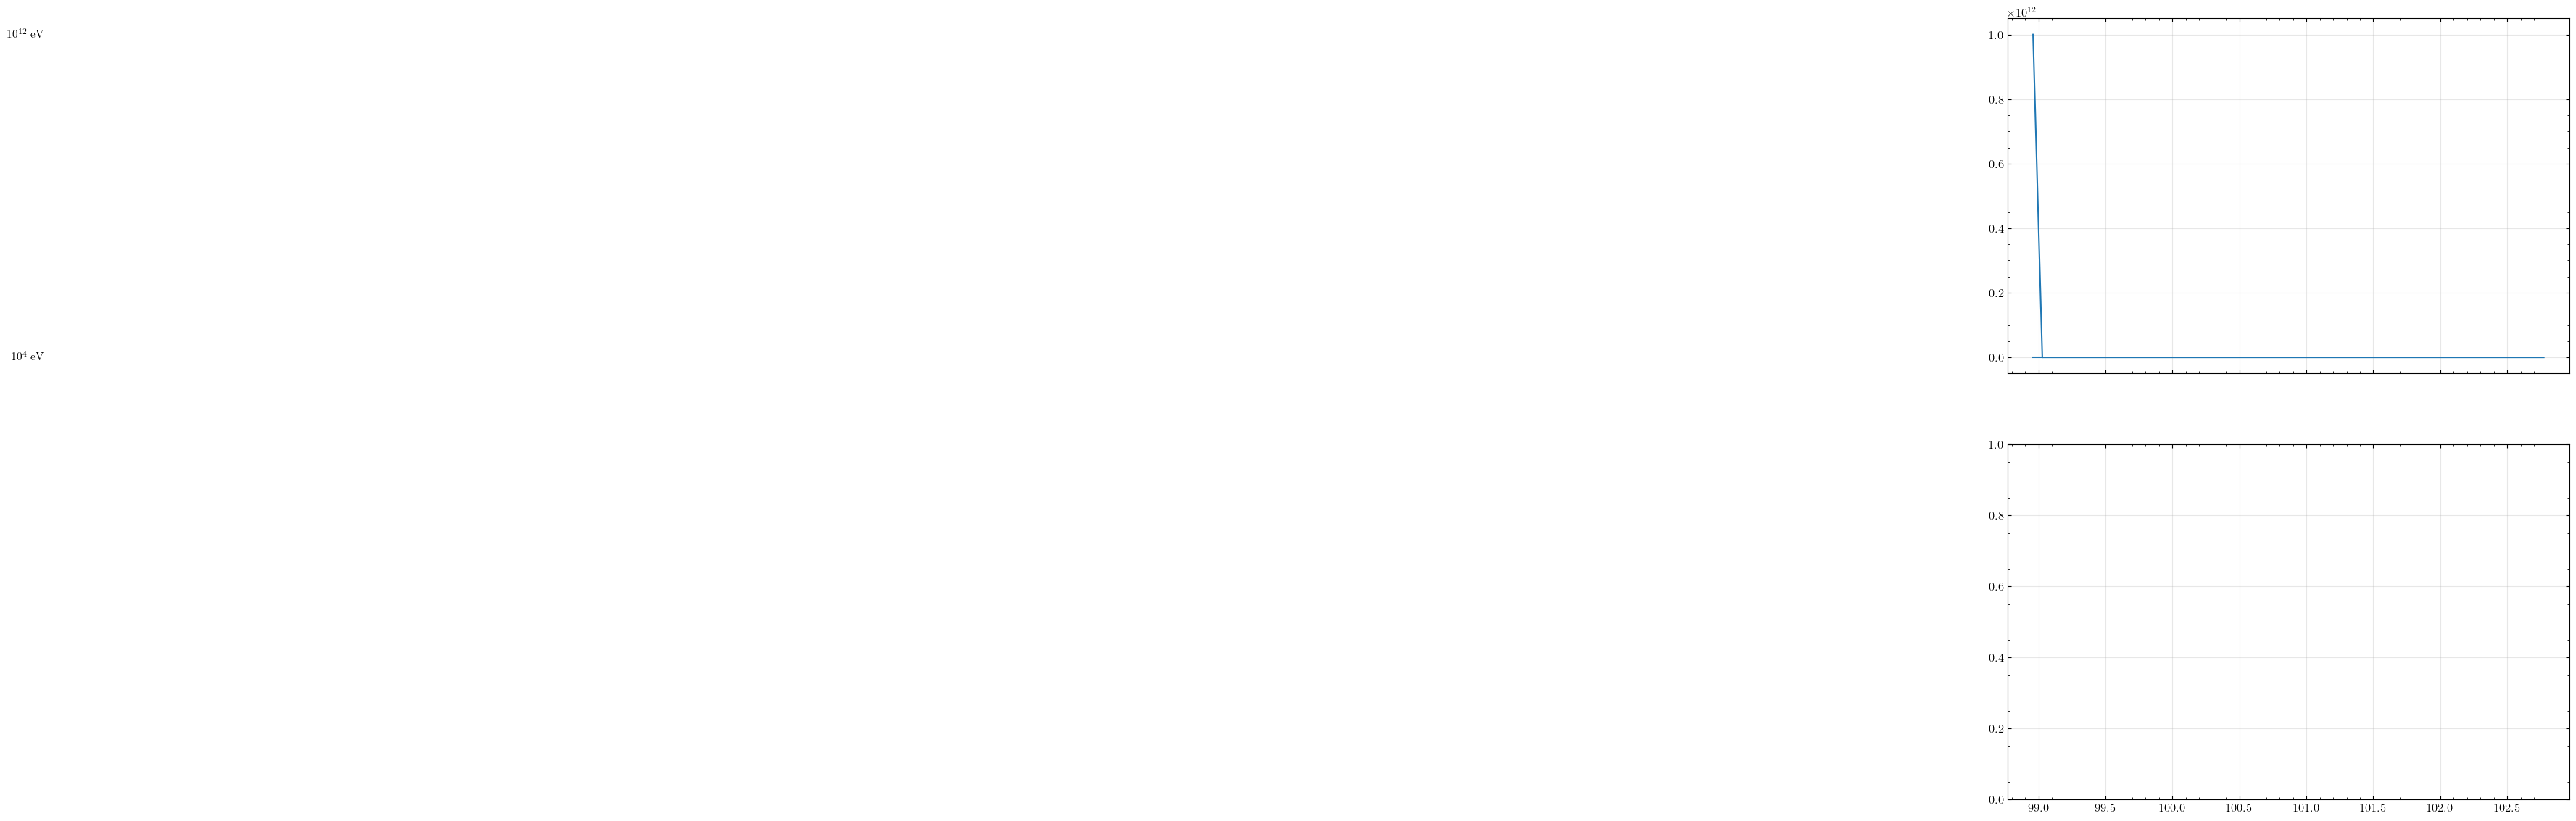

In [12]:
#--- 6. Plotting Trajectories and Gradient Mechanisms ---
print("Integrating individual trajectories...")

fig, axes = plt.subplots(2, 1, figsize=(10.0, 14.0), sharex=True)

def draw_phase_panel(ax, toggles, title):
    active_evaluator = get_cooling_rate_evaluator(toggles)
    
    initial_energies_eV = [1e12, 1e4]
    initial_redshifts = [30.0, 20.0, 10.0, 9.0, 8.0, 7.0, 6.0]
    z_end_plot = 2.0 
    
    # Map colors to initial redshift explicitly
    z_colors = {
        30.0: '#1f77b4',
        20.0: '#8c564b',
        10.0: '#1f77b4', 
        9.0: '#ff7f0e', 
        8.0: '#2ca02c', 
        7.0: '#d62728',
        6.0: '#9467bd'
    }
    
    # Conversion factor from seconds to Megayears
    SEC_TO_MYR = 1.0 / (YEAR_MKS * 1e6)
    
    for z_start in initial_redshifts:
        t_start = Planck18.age(z_start).to(u.s).value
        t_end = Planck18.age(z_end_plot).to(u.s).value
        
        t_eval = np.logspace(np.log10(t_start), np.log10(t_end), 5000)
        
        for K_ini_eV in initial_energies_eV:
            K_ini_J = K_ini_eV * EV_MKS
            
            sol = solve_ivp(active_evaluator, 
                            t_span=(t_eval[0], t_eval[-1]), 
                            y0=[K_ini_J], 
                            events=thermalization_limit,
                            dense_output=True,
                            method='Radau', 
                            rtol=1e-6, atol=1e-25)
            
            active_mask = t_eval <= sol.t[-1]
            t_active = t_eval[active_mask]
            
            # Convert integration time array to Myr for the X-axis
            t_active_myr = t_active * SEC_TO_MYR
            K_active_eV = sol.sol(t_active)[0] / EV_MKS
            
            # Plot the continuous trajectory matching the redshift color against cosmic age
            ax.plot(t_active_myr, K_active_eV, color=z_colors[z_start], lw=1.5)
            
            # Flag placement to mark the initial energy only on the highest redshift (earliest time)
            if z_start == initial_redshifts[0]:
                exp_val = int(np.log10(K_ini_eV))
                t_start_myr = t_start * SEC_TO_MYR
                # Place the text slightly to the left of the starting time
                ax.text(t_start_myr * 0.85, K_ini_eV, rf'$10^{{{exp_val}}}$ eV', fontsize=11, va='center', ha='right', color='black')

    # Formatting 
    ax.set_yscale('log')
    
    # Setting X-limits based on cosmic age (time progresses left to right)
    t_lim_min = Planck18.age(max(initial_redshifts) + 5.0).to(u.Myr).value
    t_lim_max = Planck18.age(z_end_plot).to(u.Myr).value
    ax.set_xlim(t_lim_min, 500) #t_lim_max) 
    
    ax.set_ylim(1e0, 3e13)
    ax.set_title(title, fontsize=15, pad=15)
    ax.set_xscale('log')
    ax.set_ylabel(r'Energía cinética $K_{\mathrm{e}}$ [eV]', fontsize=14)
    
    # Convert interpolation grid to Myr for background curves
    t_array_myr = t_array_interp * SEC_TO_MYR
    
    # Plot calculated kinematic curves
    line_cutoff, = ax.plot(t_array_myr, ke_cutoff_array, color='black', linestyle='--', alpha=0.8, label=r'Fotoionización secundaria')
    line_99, = ax.plot(t_array_myr, ke_99_array, color='black', linestyle='-.', alpha=0.8, label=r'99\% Upscatter a 1 keV')
    
    # Red dashed references mapped to time
    t_ref_55_myr = Planck18.age(5.5).to(u.Myr).value
    line_zref = ax.axvline(t_ref_55_myr, color='red', linestyle='--', alpha=0.5, label=r'$z_{ref}=5.5$')
    
    ax.grid(True, which="major", ls="-", alpha=0.3, color='grey')
    
    # Constructing Custom Legend mapping LineColors to Redshift Values
    legend_elements = [mlines.Line2D([0], [0], color=c, lw=2, label=rf'$z_i = {z}$') for z, c in z_colors.items()]
    legend_elements.extend([line_cutoff, line_99, line_zref])
    
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', ncol=2)

# Build Top Panel
draw_phase_panel(axes[0], cooling_toggles_baseline, "Todos los mecanismos de pérdida activos")

# Build Bottom Panel
mechanism_names = ['Exp. Adiabática', 'Sincrotrón', 'Compton', 'Coulomb (Plasma)', 'Excitación Colisional', 'Ionización Colisional']
mechanism_keys = ['adiabatic', 'synchrotron', 'compton', 'coulomb', 'excitation', 'ionization']
title_disabled = ', '.join([name for key, name in zip(mechanism_keys, mechanism_names) if not cooling_toggles_custom[key]])
draw_phase_panel(axes[1], cooling_toggles_custom, f"Sin considerar: {title_disabled}" if title_disabled else "Todos los mecanismos activos")

# Update X label for the new domain
axes[1].set_xlabel(r'Edad del Universo [Myr]', fontsize=14)

plt.tight_layout()
plt.savefig(f'electron_cooling_by_age.png', dpi=300, bbox_inches='tight')
plt.show()

Pre-calculating kernels...
Pre-calculating kinematic thresholds...
Integrating individual trajectories...


/tmp/ipykernel_6355/3182926472.py:342: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', ncol=2)


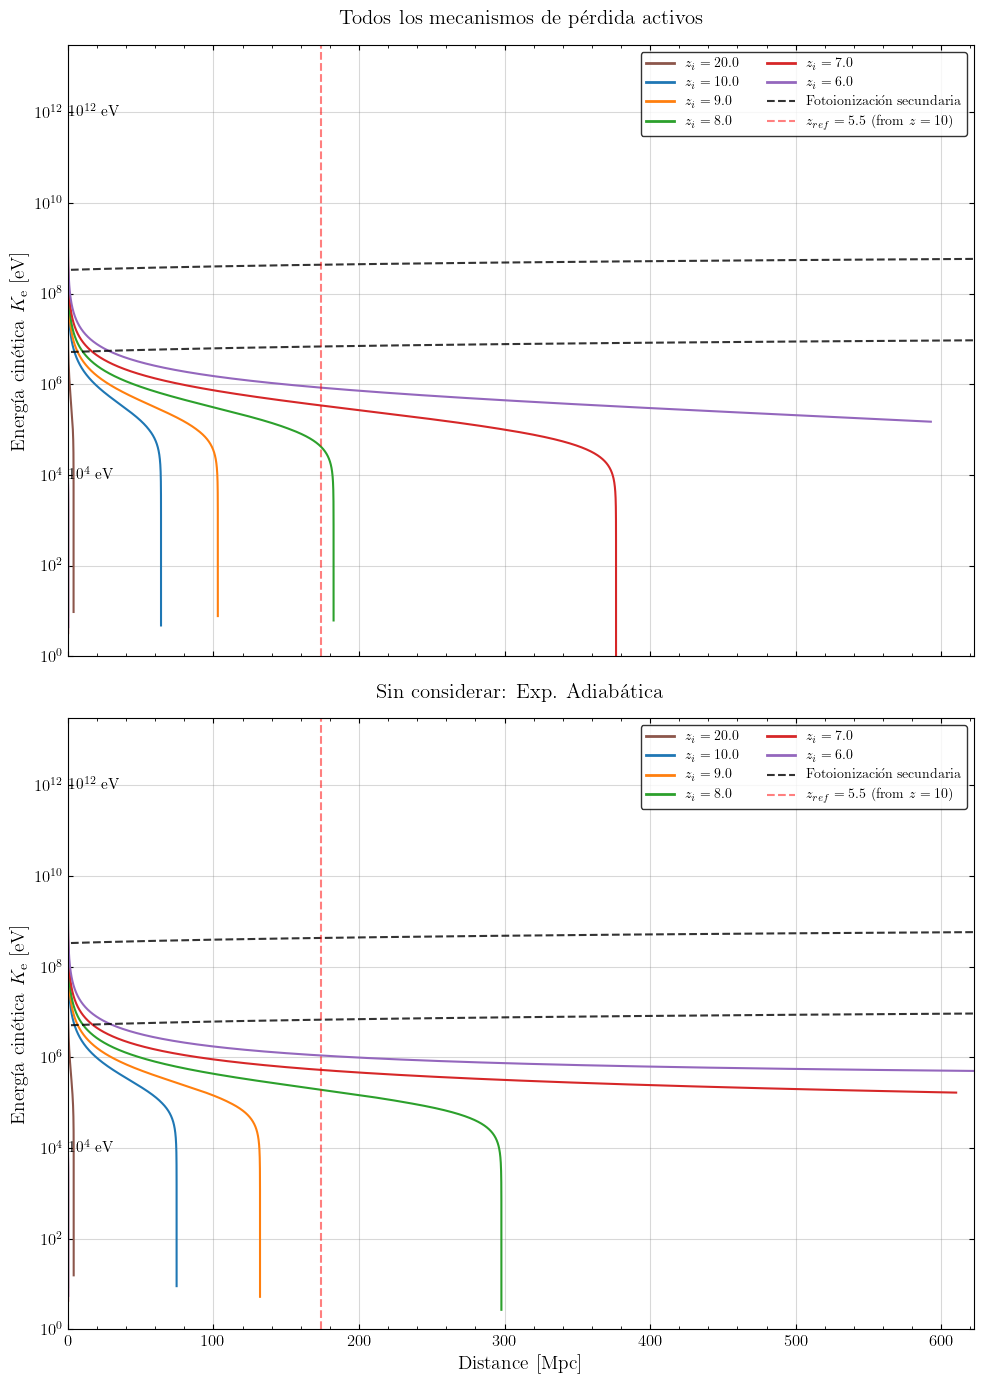

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.integrate import solve_ivp, quad, nquad, cumulative_trapezoid
from scipy.special import genlaguerre, spherical_jn, roots_laguerre
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from astropy.cosmology import Planck18
import astropy.units as u
import warnings

warnings.filterwarnings("ignore", category=IntegrationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- 1. Publication-Quality Formatting ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 14,
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "lines.linewidth": 1.5
})

# --- 2. Physical Constants (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
YEAR_MKS = 3.15569251e7
PARSEC_MKS = 3.085677581491367e16
MEGAPARSEC_MKS = 1e6 * PARSEC_MKS
VACUUM_PERMEABILITY_NORM = 1.00000000055
ELECTRON_MASS_MKS = 9.1093837139e-31
T_CMB_0 = 2.7255
U_CMB_0_J_M3 = 4.17e-14  

EV_MKS = ELECTRON_CHARGE_MKS
PLANCK_CONSTANT_REDUCED_MKS = PLANCK_CONSTANT_MKS / (2.0 * np.pi)
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS**2)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS**2 / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS**2 / (2.0 * VACUUM_PERMITTIVITY * PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS)
RY_ENERGY_MKS = FINE_STRUCTURE_CONSTANT**2 * ELECTRON_REST_ENERGY_MKS / 2.0
THOMSON_CROSS_SECTION_MKS = (8.0 * np.pi / 3.0) * ELECTRON_RADIUS_MKS**2
BOHR_RADIUS_MKS = PLANCK_CONSTANT_REDUCED_MKS / (ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * FINE_STRUCTURE_CONSTANT)

E0 = ELECTRON_REST_ENERGY_MKS

# --- Astrophysical Parameters ---
B0 = 1e-9 * 1e-4  
ION_FRACTION = 1e-4  
Z_target = 1.0 
delta_gould = 0.5 
threshold_eV_ion = RY_ENERGY_MKS / EV_MKS
threshold_eV_exc = 10.204

# Define a broad cosmological grid for interpolators
z_max_interp = 35.0
z_array_interp = np.logspace(-3, np.log10(z_max_interp), 10000)
z_array_interp = np.insert(z_array_interp, 0, 0.0)
t_array_interp = Planck18.age(z_array_interp).to(u.s).value

t_grid_sort = t_array_interp[::-1]
z_grid_sort = z_array_interp[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")
H_interp = interp1d(t_grid_sort, Planck18.H(z_grid_sort).to(u.s**-1).value, kind='cubic', fill_value="extrapolate")

# --- 3. Physics Pre-computations (Cross Sections & Kernels) ---
print("Pre-calculating kernels...")
def compute_F_KN(b_val):
    if b_val < 1e-4: return 1.0
    def integrand(q, x):
        if x < 1e-5: planck = x**2
        elif x > 100: return 0.0
        else: planck = x**3 / (np.exp(x) - 1.0)
        
        if q <= 0: return planck
        xb = x * b_val
        kernel = 2*q*np.log(q) + (1+2*q)*(1-q) + ((xb*q)**2 * (1-q))/(2*(1+xb*q))
        return planck * kernel / (1 + xb*q)**3
    res, _ = nquad(integrand, [[0, 1], [0, 100]], opts=[{'limit': 50}, {'limit': 50}])
    return res * 45.0 / (np.pi**4)

b_grid = np.logspace(-4, 4, 50)
F_KN_interp = interp1d(b_grid, np.array([compute_F_KN(b) for b in b_grid]), kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

_laguerre_x, _laguerre_w = roots_laguerre(70)
def calculate_sigma_hydrogen_universal(T, n):
    if T <= 10.204: return 0.0
    a0, R, mc2 = BOHR_RADIUS_MKS * 1e10, RY_ENERGY_MKS / EV_MKS, ELECTRON_REST_ENERGY_MKS / EV_MKS
    params = {2: [10.204, 0.4164, 0.555512, 0.271785, 0.000112], 3: [12.094, 0.0791, 0.089083, 0.060202,-0.019775]}
    if n not in params: return 0.0 
    E, f0, a_bethe, b_bethe, c_bethe = params[n]
    if T < 3000:
        q_min, q_max = (np.sqrt(T) - np.sqrt(T - E))**2 / R, (np.sqrt(T) + np.sqrt(T - E))**2 / R
        def exact_gos(Q):
            q, norm = np.sqrt(max(Q, 1e-12)), np.sqrt((2.0/n)**3 * math.factorial(n-2) / (2*n*math.factorial(n+1)))
            r = _laguerre_x / (1.0 + 1.0/n)
            poly_part = 2.0 * norm * (2.0*r/n) * genlaguerre(n-2, 3)(2.0*r/n) * spherical_jn(1, q*r) * (r**2) * np.sqrt(3)
            return ((1.0 - 1.0/(n**2)) / max(Q, 1e-12)) * (np.sum(_laguerre_w * poly_part) / (1.0 + 1.0/n))**2
        f_pwb_val, _ = quad(lambda Q: exact_gos(Q) / (E/R) / Q, q_min, q_max, limit=200)
        return (4 * np.pi * a0**2 * R / T) * f_pwb_val * (T / (T + R + E))
    elif T < 1e5:
        return ((4 * np.pi * a0**2 * R) / (T + R + E)) * (a_bethe * np.log(T / R) + b_bethe + (c_bethe * R / T))
    else:
        gamma, beta2 = 1 + (T / mc2), 1.0 - 1.0 / ((1 + (T / mc2))**2)
        return ((8 * np.pi * a0**2 / beta2) * (R / mc2)) * (a_bethe * (np.log(gamma**2 - 1.0) - beta2) + b_bethe - a_bethe * np.log(2 * R / mc2))

K_e_grid_eval = np.logspace(np.log10(10.204), 14, 500) 
loss_array_exc = np.array([sum(calculate_sigma_hydrogen_universal(K_e, n) * 1e-20 * E for n, E in zip([2,3], [10.204, 12.094]) if K_e > E) for K_e in K_e_grid_eval])
loss_interp_exc = interp1d(K_e_grid_eval, loss_array_exc, kind='linear', fill_value=0.0, bounds_error=False)

DipoleFit = [-0.0224728, 1.177455, -0.4626461, 0.08906479] 
DipoleIntegralFit = np.array([df / (j + 2) for j, df in enumerate(DipoleFit)])
DipoleIntegralSum, DipoleStrength = np.sum(DipoleIntegralFit), 2.0 - np.sum([df / (j + 1) for j, df in enumerate(DipoleFit)])
def coll_ionisation_cross_section(K):
    if K <= RY_ENERGY_MKS: return 0.0
    k, k_b, b, e = K / E0, K / RY_ENERGY_MKS, RY_ENERGY_MKS / E0, 1.0 + K / E0
    v2, bv2 = 1.0 - 1.0 / (e**2), 1.0 - 1.0 / ((1.0 + b)**2)
    integral = DipoleIntegralFit[-1]
    for i in range(2, -1, -1): integral = integral * (2.0 / (k_b + 1.0)) + DipoleIntegralFit[i]
    t1 = (np.log(0.5 * k_b * (e + 1.0)) - v2) * (DipoleIntegralSum - integral * (2.0 / (k_b + 1.0))**2)
    t2 = ((0.5 * (k_b - 1.0) * b**2 - np.log(k_b) * (e + k) / (1.0 + k_b)) / (1.0 + 0.5 * k)**2 + 1.0 - 1.0 / k_b) * DipoleStrength
    return (2.0 * np.pi * ELECTRON_RADIUS_MKS**2 / (b * (v2 + 2 * bv2))) * (t1 + t2)

loss_array_ion = []
for K_e in K_e_grid_eval:
    if K_e <= threshold_eV_ion: loss_array_ion.append(0.0)
    else:
        eps_max = (K_e - threshold_eV_ion) / 2.0
        n_int, _ = quad(lambda eps: 1.0 / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        e_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        loss_array_ion.append(coll_ionisation_cross_section(K_e * EV_MKS) * (threshold_eV_ion + (e_int/n_int if n_int>0 else 0.0)))
loss_interp_ion = interp1d(K_e_grid_eval, np.array(loss_array_ion), kind='linear', fill_value=0.0, bounds_error=False)

# --- 4. Kinematic Threshold Vectorization ---
print("Pre-calculating kinematic thresholds...")
def compute_threshold_curves(z_array, min_sim_eV=10.2, target_upscatter_eV=1e3, losing_tolerance=1e-2):
    total_planck_area = 2.4041138
    
    def planck_integrand(x):
        if x < 1e-8: return x
        return (x * x) / np.expm1(x)
        
    # 1. Roots are constant and scale-independent
    max_area = total_planck_area * (1.0 - losing_tolerance)
    res_max = root_scalar(lambda x: quad(planck_integrand, 0, x)[0] - max_area, bracket=[1e-5, 50.0])
    x_max_val = res_max.root
    
    min_area = total_planck_area * 0.01
    res_min = root_scalar(lambda x: quad(planck_integrand, 0, x)[0] - min_area, bracket=[1e-5, 10.0])
    x_min_val = res_min.root
    
    # 2. Vectorized evaluation for array of z
    cmb_energy_0 = BOLTZMANN_CONSTANT_MKS * T_CMB_0
    thermal_energy = cmb_energy_0 * (1.0 + z_array)
    
    max_photon_energy = x_max_val * thermal_energy
    min_photon_energy_99 = x_min_val * thermal_energy
    
    # param_values_6 calculation
    min_sim_J = min_sim_eV * EV_MKS
    ratio_rest_max = min_sim_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_max = min_sim_J / max_photon_energy
    g_max = ratio_rest_max + np.sqrt(ratio_rest_max**2 + ratio_phot_max)
    gamma_cut = (g_max**2 + 1.0) / (2.0 * g_max)
    ke_cutoff_array = ELECTRON_REST_ENERGY_MKS * (gamma_cut - 1.0) / EV_MKS
    
    # ke_99_percent_scatter calculation
    target_J = target_upscatter_eV * EV_MKS
    ratio_rest_min = target_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_min = target_J / min_photon_energy_99
    g_min = ratio_rest_min + np.sqrt(ratio_rest_min**2 + ratio_phot_min)
    gamma_target = (g_min**2 + 1.0) / (2.0 * g_min)
    ke_99_array = ELECTRON_REST_ENERGY_MKS * (gamma_target - 1.0) / EV_MKS
    
    return ke_cutoff_array, ke_99_array

# Compute thresholds for the global interpolation grid
ke_cutoff_array, ke_99_array = compute_threshold_curves(z_array_interp)



Integrating individual trajectories...


/tmp/ipykernel_6355/2120365899.py:150: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', ncol=2)


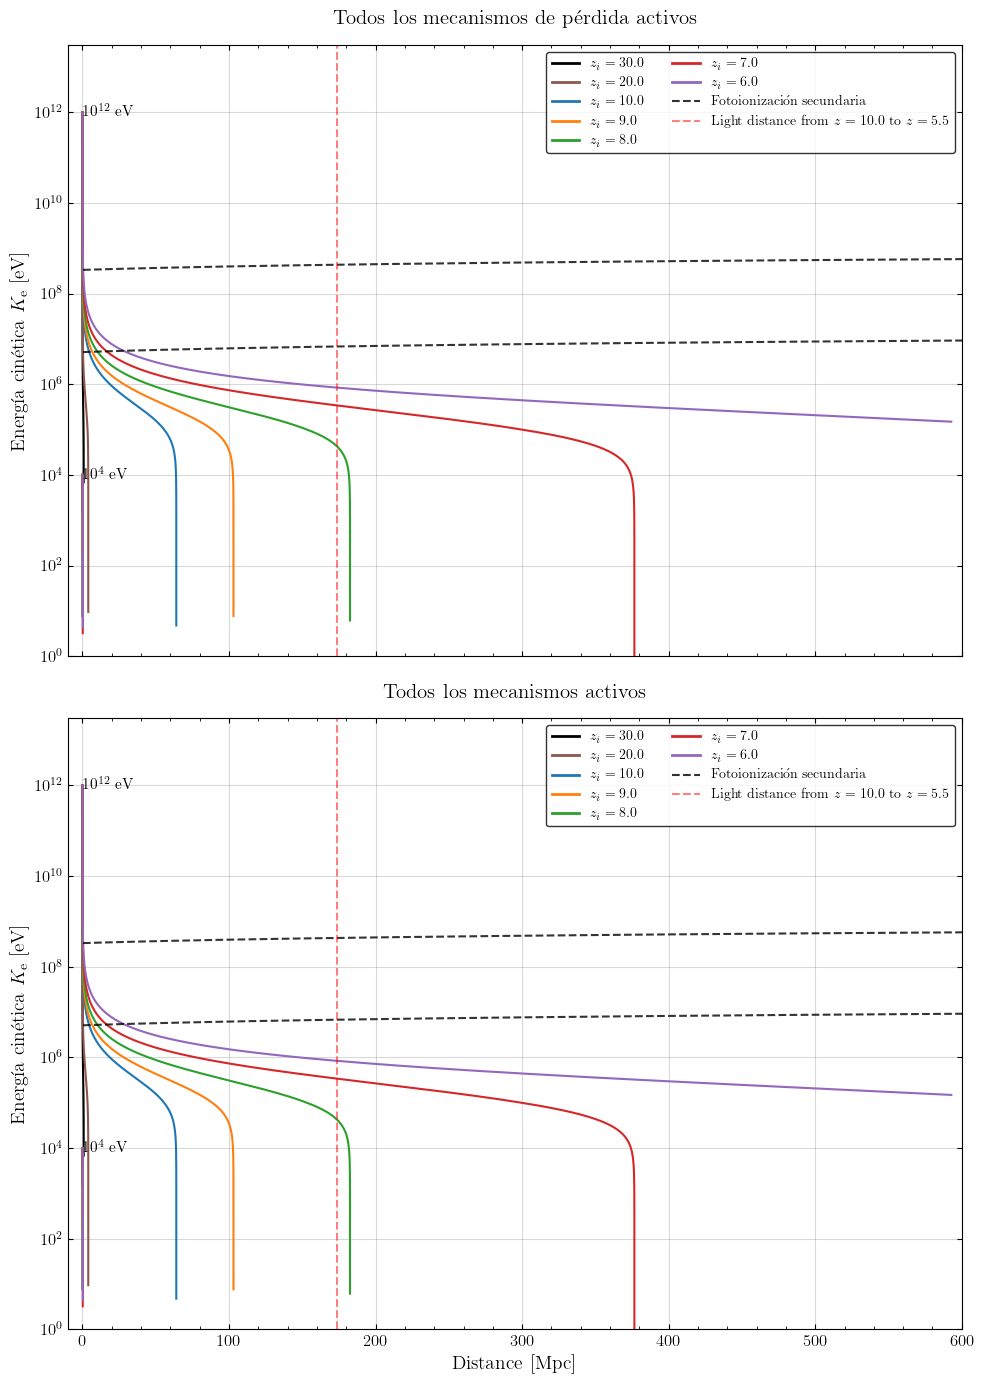

In [ ]:
# --- 5. Scalar ODE Evaluator with Toggles ---
cooling_toggles_custom = {
    'adiabatic': True,
    'synchrotron': True,
    'compton': True,
    'coulomb': True,
    'excitation': True,
    'ionization': True
}
cooling_toggles_baseline = {k: True for k in cooling_toggles_custom}

def get_cooling_rate_evaluator(toggles):
    def evaluator(t, K):
        K_val = K[0]
        if K_val <= 0: return [0.0]
        
        E_val = K_val + E0
        gamma = E_val / E0
        z = float(z_interp(t))
        
        p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
        v = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
        n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
        
        L_ad = 0.0
        if toggles['adiabatic']:
            L_ad = float(H_interp(t)) * p_sqrd_c_sqrd / E_val
            
        L_synch = 0.0
        if toggles['synchrotron']:
            U_B = ((B0 * (1 + z)**2)**2) / (2 * VACUUM_PERMEABILITY)
            L_synch = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p_sqrd_c_sqrd
            
        L_ic = 0.0
        if toggles['compton']:
            T_CMB_z, U_CMB_z = T_CMB_0 * (1.0 + z), U_CMB_0_J_M3 * (1 + z)**4
            L_ic = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z / E0**2) * p_sqrd_c_sqrd * float(F_KN_interp(4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0))
        
        L_coulomb = 0.0
        if toggles['coulomb']:
            n_e = ION_FRACTION * n_HI_z
            x = np.sqrt(K_val / E0) * v * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * np.sqrt(n_e * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS)))
            if x > 0:
                fb = math.log(x) + math.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
                L_coulomb = (n_e * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * fb / (4.0 * math.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * v**2)) * v

        K_eV = K_val / EV_MKS
        
        L_exc = 0.0
        if toggles['excitation'] and K_eV >= threshold_eV_exc:
            L_exc = max(0.0, (n_HI_z * v * float(loss_interp_exc(K_eV))) * EV_MKS)            
        L_ion = 0.0
        if toggles['ionization'] and K_eV >= threshold_eV_ion:
            L_ion = max(0.0, (n_HI_z * v * float(loss_interp_ion(K_eV))) * EV_MKS)
        return [-(L_ad + L_synch + L_ic + L_coulomb + L_exc + L_ion)]
        
    return evaluator

def thermalization_limit(t, K):
    return K[0] - (BOLTZMANN_CONSTANT_MKS * T_CMB_0 * (1.0 + z_interp(t)))
thermalization_limit.terminal = True
thermalization_limit.direction = -1

#--- 6. Plotting Trajectories and Gradient Mechanisms ---
print("Integrating individual trajectories...")

fig, axes = plt.subplots(2, 1, figsize=(10.0, 14.0), sharex=True)

def draw_phase_panel(ax, toggles, title):
    active_evaluator = get_cooling_rate_evaluator(toggles)
    
    initial_energies_eV = [1e12, 1e4]
    initial_redshifts = [30.0, 20.0, 10.0, 9.0, 8.0, 7.0, 6.0] 
    z_end_plot = 2.0 
    
    z_colors = {
        30.0: "#000000",
        20.0: '#8c564b',
        10.0: '#1f77b4', 
        9.0: '#ff7f0e', 
        8.0: '#2ca02c', 
        7.0: '#d62728',
        6.0: '#9467bd'
    }
    
    for z_start in initial_redshifts:
        t_start = Planck18.age(z_start).to(u.s).value
        t_end = Planck18.age(z_end_plot).to(u.s).value
        
        t_eval = np.logspace(np.log10(t_start), np.log10(t_end), 5000)
        
        for K_ini_eV in initial_energies_eV:
            K_ini_J = K_ini_eV * EV_MKS
            
            sol = solve_ivp(active_evaluator, 
                            t_span=(t_eval[0], t_eval[-1]), 
                            y0=[K_ini_J], 
                            events=thermalization_limit,
                            dense_output=True,
                            method='Radau', 
                            rtol=1e-6, atol=1e-25)
            
            active_mask = t_eval <= sol.t[-1]
            t_active = t_eval[active_mask]
            K_active_eV = sol.sol(t_active)[0] / EV_MKS
            
            # 1D Kinematics recalculation
            K_J = K_active_eV * EV_MKS
            E_tot = K_J + E0
            p2c2 = K_J**2 + 2 * K_J * E0
            v = LIGHT_SPEED_MKS * np.sqrt(p2c2) / E_tot
            
            # Integrating v(t) over time to get distance in Megaparsecs
            dist_m = cumulative_trapezoid(v, t_active, initial=0.0)
            dist_Mpc = dist_m / MEGAPARSEC_MKS
            
            # Plot the continuous trajectory matching the redshift color
            ax.plot(dist_Mpc, K_active_eV, color=z_colors[z_start], lw=1.5)
            
            if z_start == initial_redshifts[0]:
                exp_val = int(np.log10(K_ini_eV))
                ax.text(dist_Mpc[0] + 0.5, K_ini_eV, rf'$10^{{{exp_val}}}$ eV', fontsize=11, va='center', ha='left', color='black')

    # Formatting 
    ax.set_yscale('log')
    ax.set_xlim(-10.0, 600.0) 
    ax.set_ylim(1e0, 3e13)
    ax.set_title(title, fontsize=15, pad=15)
    ax.set_ylabel(r'Energía cinética $K_{\mathrm{e}}$ [eV]', fontsize=14)
    
    # Background Threshold Curves transformed into Distance space representing relativistic travel length from z_init=10.0
    z_ref_bg = 10.0
    t_ref_bg = Planck18.age(z_ref_bg).to(u.s).value
    mask_bg = (t_array_interp >= t_ref_bg) & (t_array_interp <= Planck18.age(z_end_plot).to(u.s).value)
    dist_bg_Mpc = LIGHT_SPEED_MKS * (t_array_interp[mask_bg] - t_ref_bg) / MEGAPARSEC_MKS

    line_cutoff, = ax.plot(dist_bg_Mpc, ke_cutoff_array[mask_bg], color='black', linestyle='--', alpha=0.8, label=r'Fotoionización secundaria')
    line_99, = ax.plot(dist_bg_Mpc, ke_99_array[mask_bg], color='black', linestyle='--', alpha=0.8)
    
    # Reference Distance mapping
    d_zref = LIGHT_SPEED_MKS * (Planck18.age(5.5).to(u.s).value - t_ref_bg) / MEGAPARSEC_MKS
    line_zref = ax.axvline(d_zref, color='red', linestyle='--', alpha=0.5, label=f'Light distance from $z={z_ref_bg}$ to $z=5.5$')
    
    ax.grid(True, which="major", ls="-", alpha=0.3, color='grey')
    
    # Constructing Custom Legend mapping LineColors to Redshift Values
    legend_elements = [mlines.Line2D([0], [0], color=c, lw=2, label=rf'$z_i = {z}$') for z, c in z_colors.items()]
    legend_elements.extend([line_cutoff, line_99, line_zref])
    
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', ncol=2)

# Build Top Panel
draw_phase_panel(axes[0], cooling_toggles_baseline, "Todos los mecanismos de pérdida activos")

# Build Bottom Panel
mechanism_names = ['Exp. Adiabática', 'Sincrotrón', 'Compton', 'Coulomb (Plasma)', 'Excitación Colisional', 'Ionización Colisional']
mechanism_keys = ['adiabatic', 'synchrotron', 'compton', 'coulomb', 'excitation', 'ionization']
title_disabled = ', '.join([name for key, name in zip(mechanism_keys, mechanism_names) if not cooling_toggles_custom[key]])
draw_phase_panel(axes[1], cooling_toggles_custom, f"Sin considerar: {title_disabled}" if title_disabled else "Todos los mecanismos activos")

axes[1].set_xlabel(r'Distance [Mpc]', fontsize=14)

plt.tight_layout()
plt.savefig(f'electron_cooling_by_distance.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.integrate import solve_ivp, quad, nquad, cumulative_trapezoid
from scipy.special import genlaguerre, spherical_jn, roots_laguerre
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from astropy.cosmology import Planck18
import astropy.units as u
import warnings

warnings.filterwarnings("ignore", category=IntegrationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- 1. Publication-Quality Formatting ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 14,
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "lines.linewidth": 1.5
})

# --- 2. Physical Constants (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
YEAR_MKS = 3.15569251e7
PARSEC_MKS = 3.085677581491367e16
MEGAPARSEC_MKS = 1e6 * PARSEC_MKS
VACUUM_PERMEABILITY_NORM = 1.00000000055
ELECTRON_MASS_MKS = 9.1093837139e-31
T_CMB_0 = 2.7255
U_CMB_0_J_M3 = 4.17e-14  

EV_MKS = ELECTRON_CHARGE_MKS
PLANCK_CONSTANT_REDUCED_MKS = PLANCK_CONSTANT_MKS / (2.0 * np.pi)
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS**2)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS**2 / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS**2 / (2.0 * VACUUM_PERMITTIVITY * PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS)
RY_ENERGY_MKS = FINE_STRUCTURE_CONSTANT**2 * ELECTRON_REST_ENERGY_MKS / 2.0
THOMSON_CROSS_SECTION_MKS = (8.0 * np.pi / 3.0) * ELECTRON_RADIUS_MKS**2
BOHR_RADIUS_MKS = PLANCK_CONSTANT_REDUCED_MKS / (ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * FINE_STRUCTURE_CONSTANT)

E0 = ELECTRON_REST_ENERGY_MKS

# --- Astrophysical Parameters ---
B0 = 1e-9 * 1e-4  
ION_FRACTION = 1e-4  
Z_target = 1.0 
delta_gould = 0.5 
threshold_eV_ion = RY_ENERGY_MKS / EV_MKS
threshold_eV_exc = 10.204



z_max_interp = 35.0
z_array_interp = np.logspace(-3, np.log10(z_max_interp), 10000)
z_array_interp = np.insert(z_array_interp, 0, 0.0)
t_array_interp = Planck18.age(z_array_interp).to(u.s).value

t_grid_sort = t_array_interp[::-1]
z_grid_sort = z_array_interp[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")
H_interp = interp1d(t_grid_sort, Planck18.H(z_grid_sort).to(u.s**-1).value, kind='cubic', fill_value="extrapolate")

# --- 3. Physics Pre-computations (Cross Sections & Kernels) ---
print("Pre-calculating kernels...")
def compute_F_KN(b_val):
    if b_val < 1e-4: return 1.0
    def integrand(q, x):
        if x < 1e-5: planck = x**2
        elif x > 100: return 0.0
        else: planck = x**3 / (np.exp(x) - 1.0)
        
        if q <= 0: return planck
        xb = x * b_val
        kernel = 2*q*np.log(q) + (1+2*q)*(1-q) + ((xb*q)**2 * (1-q))/(2*(1+xb*q))
        return planck * kernel / (1 + xb*q)**3
    res, _ = nquad(integrand, [[0, 1], [0, 100]], opts=[{'limit': 50}, {'limit': 50}])
    return res * 45.0 / (np.pi**4)

b_grid = np.logspace(-4, 4, 50)
F_KN_interp = interp1d(b_grid, np.array([compute_F_KN(b) for b in b_grid]), kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

_laguerre_x, _laguerre_w = roots_laguerre(70)
def calculate_sigma_hydrogen_universal(T, n):
    if T <= 10.204: return 0.0
    a0, R, mc2 = BOHR_RADIUS_MKS * 1e10, RY_ENERGY_MKS / EV_MKS, ELECTRON_REST_ENERGY_MKS / EV_MKS
    params = {2: [10.204, 0.4164, 0.555512, 0.271785, 0.000112], 3: [12.094, 0.0791, 0.089083, 0.060202,-0.019775]}
    if n not in params: return 0.0 
    E, f0, a_bethe, b_bethe, c_bethe = params[n]
    if T < 3000:
        q_min, q_max = (np.sqrt(T) - np.sqrt(T - E))**2 / R, (np.sqrt(T) + np.sqrt(T - E))**2 / R
        def exact_gos(Q):
            q, norm = np.sqrt(max(Q, 1e-12)), np.sqrt((2.0/n)**3 * math.factorial(n-2) / (2*n*math.factorial(n+1)))
            r = _laguerre_x / (1.0 + 1.0/n)
            poly_part = 2.0 * norm * (2.0*r/n) * genlaguerre(n-2, 3)(2.0*r/n) * spherical_jn(1, q*r) * (r**2) * np.sqrt(3)
            return ((1.0 - 1.0/(n**2)) / max(Q, 1e-12)) * (np.sum(_laguerre_w * poly_part) / (1.0 + 1.0/n))**2
        f_pwb_val, _ = quad(lambda Q: exact_gos(Q) / (E/R) / Q, q_min, q_max, limit=200)
        return (4 * np.pi * a0**2 * R / T) * f_pwb_val * (T / (T + R + E))
    elif T < 1e5:
        return ((4 * np.pi * a0**2 * R) / (T + R + E)) * (a_bethe * np.log(T / R) + b_bethe + (c_bethe * R / T))
    else:
        gamma, beta2 = 1 + (T / mc2), 1.0 - 1.0 / ((1 + (T / mc2))**2)
        return ((8 * np.pi * a0**2 / beta2) * (R / mc2)) * (a_bethe * (np.log(gamma**2 - 1.0) - beta2) + b_bethe - a_bethe * np.log(2 * R / mc2))

K_e_grid_eval = np.logspace(np.log10(10.204), 14, 500) 
loss_array_exc = np.array([sum(calculate_sigma_hydrogen_universal(K_e, n) * 1e-20 * E for n, E in zip([2,3], [10.204, 12.094]) if K_e > E) for K_e in K_e_grid_eval])
loss_interp_exc = interp1d(K_e_grid_eval, loss_array_exc, kind='linear', fill_value=0.0, bounds_error=False)

DipoleFit = [-0.0224728, 1.177455, -0.4626461, 0.08906479] 
DipoleIntegralFit = np.array([df / (j + 2) for j, df in enumerate(DipoleFit)])
DipoleIntegralSum, DipoleStrength = np.sum(DipoleIntegralFit), 2.0 - np.sum([df / (j + 1) for j, df in enumerate(DipoleFit)])
def coll_ionisation_cross_section(K):
    if K <= RY_ENERGY_MKS: return 0.0
    k, k_b, b, e = K / E0, K / RY_ENERGY_MKS, RY_ENERGY_MKS / E0, 1.0 + K / E0
    v2, bv2 = 1.0 - 1.0 / (e**2), 1.0 - 1.0 / ((1.0 + b)**2)
    integral = DipoleIntegralFit[-1]
    for i in range(2, -1, -1): integral = integral * (2.0 / (k_b + 1.0)) + DipoleIntegralFit[i]
    t1 = (np.log(0.5 * k_b * (e + 1.0)) - v2) * (DipoleIntegralSum - integral * (2.0 / (k_b + 1.0))**2)
    t2 = ((0.5 * (k_b - 1.0) * b**2 - np.log(k_b) * (e + k) / (1.0 + k_b)) / (1.0 + 0.5 * k)**2 + 1.0 - 1.0 / k_b) * DipoleStrength
    return (2.0 * np.pi * ELECTRON_RADIUS_MKS**2 / (b * (v2 + 2 * bv2))) * (t1 + t2)

loss_array_ion = []
for K_e in K_e_grid_eval:
    if K_e <= threshold_eV_ion: loss_array_ion.append(0.0)
    else:
        eps_max = (K_e - threshold_eV_ion) / 2.0
        n_int, _ = quad(lambda eps: 1.0 / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        e_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        loss_array_ion.append(coll_ionisation_cross_section(K_e * EV_MKS) * (threshold_eV_ion + (e_int/n_int if n_int>0 else 0.0)))
loss_interp_ion = interp1d(K_e_grid_eval, np.array(loss_array_ion), kind='linear', fill_value=0.0, bounds_error=False)

# --- 4. Kinematic Threshold Vectorization ---
print("Pre-calculating kinematic thresholds...")
def compute_threshold_curves(z_array, min_sim_eV=10.2, target_upscatter_eV=1e3, losing_tolerance=1e-2):
    total_planck_area = 2.4041138
    
    def planck_integrand(x):
        if x < 1e-8: return x
        return (x * x) / np.expm1(x)
        
    # 1. Roots are constant and scale-independent
    max_area = total_planck_area * (1.0 - losing_tolerance)
    res_max = root_scalar(lambda x: quad(planck_integrand, 0, x)[0] - max_area, bracket=[1e-5, 50.0])
    x_max_val = res_max.root
    
    min_area = total_planck_area * 0.01
    res_min = root_scalar(lambda x: quad(planck_integrand, 0, x)[0] - min_area, bracket=[1e-5, 10.0])
    x_min_val = res_min.root
    
    # 2. Vectorized evaluation for array of z
    cmb_energy_0 = BOLTZMANN_CONSTANT_MKS * T_CMB_0
    thermal_energy = cmb_energy_0 * (1.0 + z_array)
    
    max_photon_energy = x_max_val * thermal_energy
    min_photon_energy_99 = x_min_val * thermal_energy
    
    # param_values_6 calculation
    min_sim_J = min_sim_eV * EV_MKS
    ratio_rest_max = min_sim_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_max = min_sim_J / max_photon_energy
    g_max = ratio_rest_max + np.sqrt(ratio_rest_max**2 + ratio_phot_max)
    gamma_cut = (g_max**2 + 1.0) / (2.0 * g_max)
    ke_cutoff_array = ELECTRON_REST_ENERGY_MKS * (gamma_cut - 1.0) / EV_MKS
    
    # ke_99_percent_scatter calculation
    target_J = target_upscatter_eV * EV_MKS
    ratio_rest_min = target_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_min = target_J / min_photon_energy_99
    g_min = ratio_rest_min + np.sqrt(ratio_rest_min**2 + ratio_phot_min)
    gamma_target = (g_min**2 + 1.0) / (2.0 * g_min)
    ke_99_array = ELECTRON_REST_ENERGY_MKS * (gamma_target - 1.0) / EV_MKS
    
    return ke_cutoff_array, ke_99_array

# Compute thresholds for the global interpolation grid
ke_cutoff_array, ke_99_array = compute_threshold_curves(z_array_interp)


Pre-calculating kernels...
Pre-calculating kinematic thresholds...


Integrating individual trajectories...


/tmp/ipykernel_6355/3519389389.py:163: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', ncol=2)


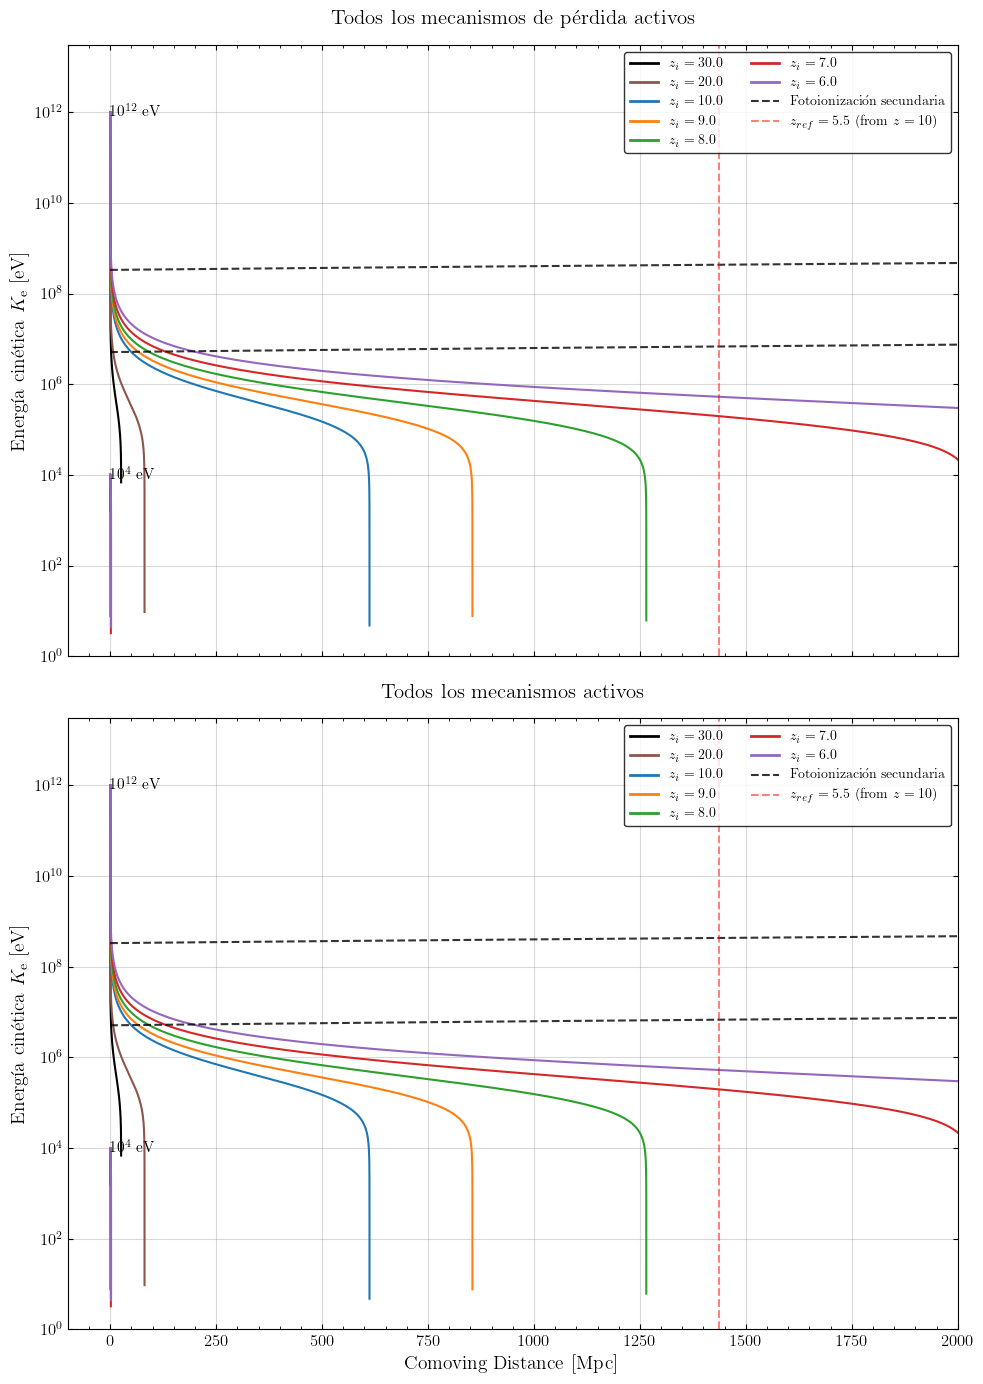

In [ ]:

# --- 5. Scalar ODE Evaluator with Toggles ---
cooling_toggles_custom = {
    'adiabatic': True,
    'synchrotron': True,
    'compton': True,
    'coulomb': True,
    'excitation': True,
    'ionization': True
}
cooling_toggles_baseline = {k: True for k in cooling_toggles_custom}

def get_cooling_rate_evaluator(toggles):
    def evaluator(t, K):
        K_val = K[0]
        if K_val <= 0: return [0.0]
        
        E_val = K_val + E0
        gamma = E_val / E0
        z = float(z_interp(t))
        
        p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
        v = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
        n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
        
        L_ad = 0.0
        if toggles['adiabatic']:
            L_ad = float(H_interp(t)) * p_sqrd_c_sqrd / E_val
            
        L_synch = 0.0
        if toggles['synchrotron']:
            U_B = ((B0 * (1 + z)**2)**2) / (2 * VACUUM_PERMEABILITY)
            L_synch = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p_sqrd_c_sqrd
            
        L_ic = 0.0
        if toggles['compton']:
            T_CMB_z, U_CMB_z = T_CMB_0 * (1.0 + z), U_CMB_0_J_M3 * (1 + z)**4
            L_ic = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z / E0**2) * p_sqrd_c_sqrd * float(F_KN_interp(4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0))
        
        L_coulomb = 0.0
        if toggles['coulomb']:
            n_e = ION_FRACTION * n_HI_z
            x = np.sqrt(K_val / E0) * v * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * np.sqrt(n_e * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS)))
            if x > 0:
                fb = math.log(x) + math.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
                L_coulomb = (n_e * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * fb / (4.0 * math.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * v**2)) * v

        K_eV = K_val / EV_MKS
        
        L_exc = 0.0
        if toggles['excitation'] and K_eV >= threshold_eV_exc:
            L_exc = max(0.0, (n_HI_z * v * float(loss_interp_exc(K_eV))) * EV_MKS)            
        L_ion = 0.0
        if toggles['ionization'] and K_eV >= threshold_eV_ion:
            L_ion = max(0.0, (n_HI_z * v * float(loss_interp_ion(K_eV))) * EV_MKS)
        return [-(L_ad + L_synch + L_ic + L_coulomb + L_exc + L_ion)]
        
    return evaluator

def thermalization_limit(t, K):
    return K[0] - (BOLTZMANN_CONSTANT_MKS * T_CMB_0 * (1.0 + z_interp(t)))
thermalization_limit.terminal = True
thermalization_limit.direction = -1


#--- 6. Plotting Trajectories and Gradient Mechanisms ---
print("Integrating individual trajectories...")

fig, axes = plt.subplots(2, 1, figsize=(10.0, 14.0), sharex=True)

def draw_phase_panel(ax, toggles, title):
    active_evaluator = get_cooling_rate_evaluator(toggles)
    
    initial_energies_eV = [1e12, 1e4]
    initial_redshifts = [30.0, 20.0, 10.0, 9.0, 8.0, 7.0, 6.0] 
    z_end_plot = 2.0 
    
    z_colors = {
        30.0: '#000000',
        20.0: '#8c564b',
        10.0: '#1f77b4', 
        9.0: '#ff7f0e', 
        8.0: '#2ca02c', 
        7.0: '#d62728',
        6.0: '#9467bd'
    }
    
    for z_start in initial_redshifts:
        t_start = Planck18.age(z_start).to(u.s).value
        t_end = Planck18.age(z_end_plot).to(u.s).value
        
        t_eval = np.logspace(np.log10(t_start), np.log10(t_end), 5000)
        
        for K_ini_eV in initial_energies_eV:
            K_ini_J = K_ini_eV * EV_MKS
            
            sol = solve_ivp(active_evaluator, 
                            t_span=(t_eval[0], t_eval[-1]), 
                            y0=[K_ini_J], 
                            events=thermalization_limit,
                            dense_output=True,
                            method='Radau', 
                            rtol=1e-6, atol=1e-25)
            
            active_mask = t_eval <= sol.t[-1]
            t_active = t_eval[active_mask]
            K_active_eV = sol.sol(t_active)[0] / EV_MKS
            z_active = z_interp(t_active)
            
            # 1D Kinematics recalculation
            K_J = K_active_eV * EV_MKS
            E_tot = K_J + E0
            p2c2 = K_J**2 + 2 * K_J * E0
            v = LIGHT_SPEED_MKS * np.sqrt(p2c2) / E_tot
            
            # Integrating v(t) * (1+z) over time to get COMOVING distance in Megaparsecs
            v_comoving = v * (1.0 + z_active)
            dist_m = cumulative_trapezoid(v_comoving, t_active, initial=0.0)
            dist_Mpc = dist_m / MEGAPARSEC_MKS
            
            # Plot the continuous trajectory matching the redshift color
            ax.plot(dist_Mpc, K_active_eV, color=z_colors[z_start], lw=1.5)
            
            if z_start == initial_redshifts[0]:
                exp_val = int(np.log10(K_ini_eV))
                ax.text(dist_Mpc[0] + 0.5, K_ini_eV, rf'$10^{{{exp_val}}}$ eV', fontsize=11, va='center', ha='left', color='black')

    # Formatting 
    ax.set_yscale('log')
    ax.set_xlim(-100.0, 2000.0) 
    ax.set_ylim(1e0, 3e13)
    ax.set_title(title, fontsize=15, pad=15)
    ax.set_ylabel(r'Energía cinética $K_{\mathrm{e}}$ [eV]', fontsize=14)
    
    # Background Threshold Curves transformed into Comoving Distance space representing relativistic travel length from z_init=10.0
    z_ref_bg = 10.0
    t_ref_bg = Planck18.age(z_ref_bg).to(u.s).value
    t_end_bg = Planck18.age(z_end_plot).to(u.s).value
    
    # Generate an explicit forward-flowing time array to evaluate the background distance 
    t_bg = np.linspace(t_ref_bg, t_end_bg, 2000)
    z_bg = z_interp(t_bg)
    
    ke_cutoff_bg, ke_99_bg = compute_threshold_curves(z_bg)
    
    v_c_comoving = LIGHT_SPEED_MKS * (1.0 + z_bg)
    dist_bg_Mpc = cumulative_trapezoid(v_c_comoving, t_bg, initial=0.0) / MEGAPARSEC_MKS

    line_cutoff, = ax.plot(dist_bg_Mpc, ke_cutoff_bg, color='black', linestyle='--', alpha=0.8, label=r'Fotoionización secundaria')
    line_99, = ax.plot(dist_bg_Mpc, ke_99_bg, color='black', linestyle='--', alpha=0.8)
    
    # Reference Distance mapping
    t_zref = Planck18.age(5.5).to(u.s).value
    t_zref_arr = np.linspace(t_ref_bg, t_zref, 1000)
    d_zref = cumulative_trapezoid(LIGHT_SPEED_MKS * (1.0 + z_interp(t_zref_arr)), t_zref_arr, initial=0.0)[-1] / MEGAPARSEC_MKS
    line_zref = ax.axvline(d_zref, color='red', linestyle='--', alpha=0.5, label=r'$z_{ref}=5.5$ (from $z=10$)')
    
    ax.grid(True, which="major", ls="-", alpha=0.3, color='grey')
    
    # Constructing Custom Legend mapping LineColors to Redshift Values
    legend_elements = [mlines.Line2D([0], [0], color=c, lw=2, label=rf'$z_i = {z}$') for z, c in z_colors.items()]
    legend_elements.extend([line_cutoff, line_99, line_zref])
    
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', ncol=2)

# Build Top Panel
draw_phase_panel(axes[0], cooling_toggles_baseline, "Todos los mecanismos de pérdida activos")

# Build Bottom Panel
mechanism_names = ['Exp. Adiabática', 'Sincrotrón', 'Compton', 'Coulomb (Plasma)', 'Excitación Colisional', 'Ionización Colisional']
mechanism_keys = ['adiabatic', 'synchrotron', 'compton', 'coulomb', 'excitation', 'ionization']
title_disabled = ', '.join([name for key, name in zip(mechanism_keys, mechanism_names) if not cooling_toggles_custom[key]])
draw_phase_panel(axes[1], cooling_toggles_custom, f"Sin considerar: {title_disabled}" if title_disabled else "Todos los mecanismos activos")

axes[1].set_xlabel(r'Comoving Distance [Mpc]', fontsize=14)

plt.tight_layout()
plt.savefig(f'electron_cooling_by_comoving_distance.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.integrate import solve_ivp, quad, nquad, cumulative_trapezoid
from scipy.special import genlaguerre, spherical_jn, roots_laguerre
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from astropy.cosmology import Planck18
import astropy.units as u
import warnings

warnings.filterwarnings("ignore", category=IntegrationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- 1. Publication-Quality Formatting ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 14,
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "lines.linewidth": 1.5
})

# --- 2. Physical Constants (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
YEAR_MKS = 3.15569251e7
VACUUM_PERMEABILITY_NORM = 1.00000000055
ELECTRON_MASS_MKS = 9.1093837139e-31
T_CMB_0 = 2.7255
U_CMB_0_J_M3 = 4.17e-14  

EV_MKS = ELECTRON_CHARGE_MKS
PLANCK_CONSTANT_REDUCED_MKS = PLANCK_CONSTANT_MKS / (2.0 * np.pi)
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS**2)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS**2 / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS**2 / (2.0 * VACUUM_PERMITTIVITY * PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS)
RY_ENERGY_MKS = FINE_STRUCTURE_CONSTANT**2 * ELECTRON_REST_ENERGY_MKS / 2.0
THOMSON_CROSS_SECTION_MKS = (8.0 * np.pi / 3.0) * ELECTRON_RADIUS_MKS**2
BOHR_RADIUS_MKS = PLANCK_CONSTANT_REDUCED_MKS / (ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * FINE_STRUCTURE_CONSTANT)

E0 = ELECTRON_REST_ENERGY_MKS

# --- Astrophysical Parameters ---
B0 = 1e-9 * 1e-4  
ION_FRACTION = 1e-4  
Z_target = 1.0 
delta_gould = 0.5 
threshold_eV_ion = RY_ENERGY_MKS / EV_MKS
threshold_eV_exc = 10.204

PARSEC_MKS = 3.085677581491367e16
MEGAPARSEC_MKS = 1e6 * PARSEC_MKS

# Define a broad cosmological grid for interpolators
z_max_interp = 35.0
z_array_interp = np.logspace(-3, np.log10(z_max_interp), 10000)
z_array_interp = np.insert(z_array_interp, 0, 0.0)
t_array_interp = Planck18.age(z_array_interp).to(u.s).value

t_grid_sort = t_array_interp[::-1]
z_grid_sort = z_array_interp[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")
H_interp = interp1d(t_grid_sort, Planck18.H(z_grid_sort).to(u.s**-1).value, kind='cubic', fill_value="extrapolate")

# --- 3. Physics Pre-computations (Cross Sections & Kernels) ---
print("Pre-calculating kernels...")
def compute_F_KN(b_val):
    if b_val < 1e-4: return 1.0
    def integrand(q, x):
        if x < 1e-5: planck = x**2
        elif x > 100: return 0.0
        else: planck = x**3 / (np.exp(x) - 1.0)
        
        if q <= 0: return planck
        xb = x * b_val
        kernel = 2*q*np.log(q) + (1+2*q)*(1-q) + ((xb*q)**2 * (1-q))/(2*(1+xb*q))
        return planck * kernel / (1 + xb*q)**3
    res, _ = nquad(integrand, [[0, 1], [0, 100]], opts=[{'limit': 50}, {'limit': 50}])
    return res * 45.0 / (np.pi**4)

b_grid = np.logspace(-4, 4, 50)
F_KN_interp = interp1d(b_grid, np.array([compute_F_KN(b) for b in b_grid]), kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

_laguerre_x, _laguerre_w = roots_laguerre(70)
def calculate_sigma_hydrogen_universal(T, n):
    if T <= 10.204: return 0.0
    a0, R, mc2 = BOHR_RADIUS_MKS * 1e10, RY_ENERGY_MKS / EV_MKS, ELECTRON_REST_ENERGY_MKS / EV_MKS
    params = {2: [10.204, 0.4164, 0.555512, 0.271785, 0.000112], 3: [12.094, 0.0791, 0.089083, 0.060202,-0.019775]}
    if n not in params: return 0.0 
    E, f0, a_bethe, b_bethe, c_bethe = params[n]
    if T < 3000:
        q_min, q_max = (np.sqrt(T) - np.sqrt(T - E))**2 / R, (np.sqrt(T) + np.sqrt(T - E))**2 / R
        def exact_gos(Q):
            q, norm = np.sqrt(max(Q, 1e-12)), np.sqrt((2.0/n)**3 * math.factorial(n-2) / (2*n*math.factorial(n+1)))
            r = _laguerre_x / (1.0 + 1.0/n)
            poly_part = 2.0 * norm * (2.0*r/n) * genlaguerre(n-2, 3)(2.0*r/n) * spherical_jn(1, q*r) * (r**2) * np.sqrt(3)
            return ((1.0 - 1.0/(n**2)) / max(Q, 1e-12)) * (np.sum(_laguerre_w * poly_part) / (1.0 + 1.0/n))**2
        f_pwb_val, _ = quad(lambda Q: exact_gos(Q) / (E/R) / Q, q_min, q_max, limit=200)
        return (4 * np.pi * a0**2 * R / T) * f_pwb_val * (T / (T + R + E))
    elif T < 1e5:
        return ((4 * np.pi * a0**2 * R) / (T + R + E)) * (a_bethe * np.log(T / R) + b_bethe + (c_bethe * R / T))
    else:
        gamma, beta2 = 1 + (T / mc2), 1.0 - 1.0 / ((1 + (T / mc2))**2)
        return ((8 * np.pi * a0**2 / beta2) * (R / mc2)) * (a_bethe * (np.log(gamma**2 - 1.0) - beta2) + b_bethe - a_bethe * np.log(2 * R / mc2))

K_e_grid_eval = np.logspace(np.log10(10.204), 14, 500) 
loss_array_exc = np.array([sum(calculate_sigma_hydrogen_universal(K_e, n) * 1e-20 * E for n, E in zip([2,3], [10.204, 12.094]) if K_e > E) for K_e in K_e_grid_eval])
loss_interp_exc = interp1d(K_e_grid_eval, loss_array_exc, kind='linear', fill_value=0.0, bounds_error=False)

DipoleFit = [-0.0224728, 1.177455, -0.4626461, 0.08906479] 
DipoleIntegralFit = np.array([df / (j + 2) for j, df in enumerate(DipoleFit)])
DipoleIntegralSum, DipoleStrength = np.sum(DipoleIntegralFit), 2.0 - np.sum([df / (j + 1) for j, df in enumerate(DipoleFit)])
def coll_ionisation_cross_section(K):
    if K <= RY_ENERGY_MKS: return 0.0
    k, k_b, b, e = K / E0, K / RY_ENERGY_MKS, RY_ENERGY_MKS / E0, 1.0 + K / E0
    v2, bv2 = 1.0 - 1.0 / (e**2), 1.0 - 1.0 / ((1.0 + b)**2)
    integral = DipoleIntegralFit[-1]
    for i in range(2, -1, -1): integral = integral * (2.0 / (k_b + 1.0)) + DipoleIntegralFit[i]
    t1 = (np.log(0.5 * k_b * (e + 1.0)) - v2) * (DipoleIntegralSum - integral * (2.0 / (k_b + 1.0))**2)
    t2 = ((0.5 * (k_b - 1.0) * b**2 - np.log(k_b) * (e + k) / (1.0 + k_b)) / (1.0 + 0.5 * k)**2 + 1.0 - 1.0 / k_b) * DipoleStrength
    return (2.0 * np.pi * ELECTRON_RADIUS_MKS**2 / (b * (v2 + 2 * bv2))) * (t1 + t2)

loss_array_ion = []
for K_e in K_e_grid_eval:
    if K_e <= threshold_eV_ion: loss_array_ion.append(0.0)
    else:
        eps_max = (K_e - threshold_eV_ion) / 2.0
        n_int, _ = quad(lambda eps: 1.0 / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        e_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        loss_array_ion.append(coll_ionisation_cross_section(K_e * EV_MKS) * (threshold_eV_ion + (e_int/n_int if n_int>0 else 0.0)))
loss_interp_ion = interp1d(K_e_grid_eval, np.array(loss_array_ion), kind='linear', fill_value=0.0, bounds_error=False)

# --- 4. Kinematic Threshold Vectorization ---
print("Pre-calculating kinematic thresholds...")
def compute_threshold_curves(z_array, min_sim_eV=10.2, target_upscatter_eV=1e3, losing_tolerance=1e-2):
    total_planck_area = 2.4041138
    
    def planck_integrand(x):
        if x < 1e-8: return x
        return (x * x) / np.expm1(x)
        
    max_area = total_planck_area * (1.0 - losing_tolerance)
    res_max = root_scalar(lambda x: quad(planck_integrand, 0, x)[0] - max_area, bracket=[1e-5, 50.0])
    x_max_val = res_max.root
    
    min_area = total_planck_area * 0.01
    res_min = root_scalar(lambda x: quad(planck_integrand, 0, x)[0] - min_area, bracket=[1e-5, 10.0])
    x_min_val = res_min.root
    
    cmb_energy_0 = BOLTZMANN_CONSTANT_MKS * T_CMB_0
    thermal_energy = cmb_energy_0 * (1.0 + z_array)
    
    max_photon_energy = x_max_val * thermal_energy
    min_photon_energy_99 = x_min_val * thermal_energy
    
    min_sim_J = min_sim_eV * EV_MKS
    ratio_rest_max = min_sim_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_max = min_sim_J / max_photon_energy
    g_max = ratio_rest_max + np.sqrt(ratio_rest_max**2 + ratio_phot_max)
    gamma_cut = (g_max**2 + 1.0) / (2.0 * g_max)
    ke_cutoff_array = ELECTRON_REST_ENERGY_MKS * (gamma_cut - 1.0) / EV_MKS
    
    target_J = target_upscatter_eV * EV_MKS
    ratio_rest_min = target_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_min = target_J / min_photon_energy_99
    g_min = ratio_rest_min + np.sqrt(ratio_rest_min**2 + ratio_phot_min)
    gamma_target = (g_min**2 + 1.0) / (2.0 * g_min)
    ke_99_array = ELECTRON_REST_ENERGY_MKS * (gamma_target - 1.0) / EV_MKS
    
    return ke_cutoff_array, ke_99_array

ke_cutoff_array, ke_99_array = compute_threshold_curves(z_array_interp)



Pre-calculating kernels...
Pre-calculating kinematic thresholds...


Integrating individual trajectories...


/tmp/ipykernel_6355/3850911667.py:170: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', ncol=2)


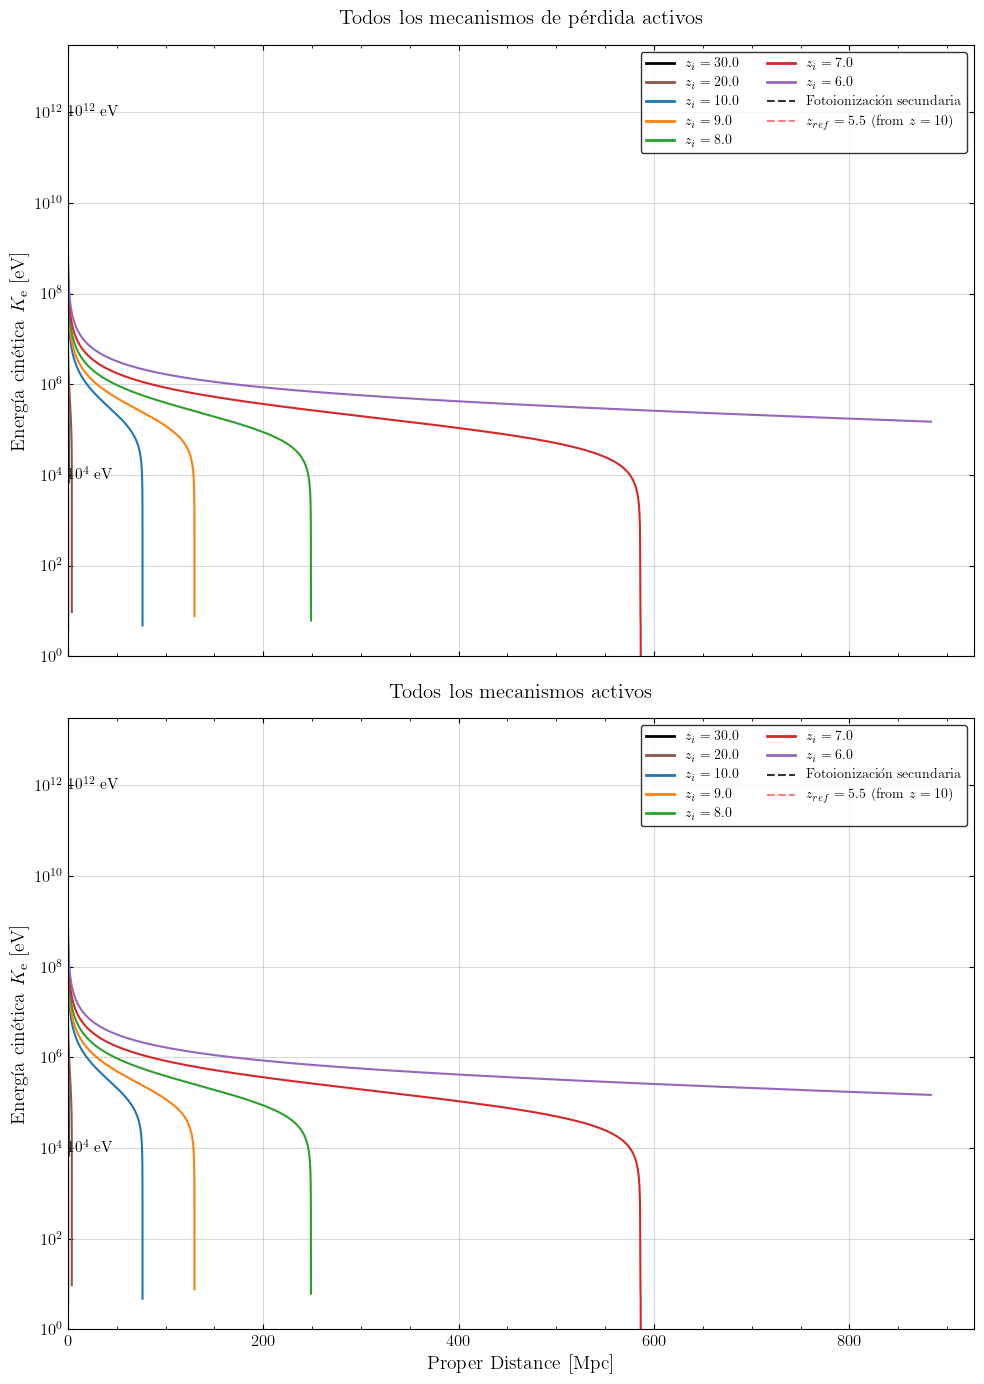

In [ ]:
# --- 5. Scalar ODE Evaluator with Toggles ---
cooling_toggles_custom = {
    'adiabatic': True,
    'synchrotron': True,
    'compton': True,
    'coulomb': True,
    'excitation': True,
    'ionization': True
}
cooling_toggles_baseline = {k: True for k in cooling_toggles_custom}

def get_cooling_rate_evaluator(toggles):
    def evaluator(t, K):
        K_val = K[0]
        if K_val <= 0: return [0.0]
        
        E_val = K_val + E0
        gamma = E_val / E0
        z = float(z_interp(t))
        
        p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
        v = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
        n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
        
        L_ad = 0.0
        if toggles['adiabatic']:
            L_ad = float(H_interp(t)) * p_sqrd_c_sqrd / E_val
            
        L_synch = 0.0
        if toggles['synchrotron']:
            U_B = ((B0 * (1 + z)**2)**2) / (2 * VACUUM_PERMEABILITY)
            L_synch = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p_sqrd_c_sqrd
            
        L_ic = 0.0
        if toggles['compton']:
            T_CMB_z, U_CMB_z = T_CMB_0 * (1.0 + z), U_CMB_0_J_M3 * (1 + z)**4
            L_ic = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z / E0**2) * p_sqrd_c_sqrd * float(F_KN_interp(4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0))
        
        L_coulomb = 0.0
        if toggles['coulomb']:
            n_e = ION_FRACTION * n_HI_z
            x = np.sqrt(K_val / E0) * v * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * np.sqrt(n_e * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS)))
            if x > 0:
                fb = math.log(x) + math.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
                L_coulomb = (n_e * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * fb / (4.0 * math.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * v**2)) * v

        K_eV = K_val / EV_MKS
        
        L_exc = 0.0
        if toggles['excitation'] and K_eV >= threshold_eV_exc:
            L_exc = max(0.0, (n_HI_z * v * float(loss_interp_exc(K_eV))) * EV_MKS)            
        L_ion = 0.0
        if toggles['ionization'] and K_eV >= threshold_eV_ion:
            L_ion = max(0.0, (n_HI_z * v * float(loss_interp_ion(K_eV))) * EV_MKS)
        return [-(L_ad + L_synch + L_ic + L_coulomb + L_exc + L_ion)]
        
    return evaluator

def thermalization_limit(t, K):
    return K[0] - (BOLTZMANN_CONSTANT_MKS * T_CMB_0 * (1.0 + z_interp(t)))
thermalization_limit.terminal = True
thermalization_limit.direction = -1


#--- 6. Plotting Trajectories and Gradient Mechanisms ---
print("Integrating individual trajectories...")

fig, axes = plt.subplots(2, 1, figsize=(10.0, 14.0), sharex=True)

def draw_phase_panel(ax, toggles, title):
    active_evaluator = get_cooling_rate_evaluator(toggles)
    
    initial_energies_eV = [1e12, 1e4]
    initial_redshifts = [30.0, 20.0, 10.0, 9.0, 8.0, 7.0, 6.0] 
    z_end_plot = 2.0 
    
    z_colors = {
        30.0: "#000000",
        20.0: '#8c564b',
        10.0: '#1f77b4', 
        9.0: '#ff7f0e', 
        8.0: '#2ca02c', 
        7.0: '#d62728',
        6.0: '#9467bd'
    }
    
    for z_start in initial_redshifts:
        t_start = Planck18.age(z_start).to(u.s).value
        t_end = Planck18.age(z_end_plot).to(u.s).value
        
        t_eval = np.logspace(np.log10(t_start), np.log10(t_end), 5000)
        
        for K_ini_eV in initial_energies_eV:
            K_ini_J = K_ini_eV * EV_MKS
            
            sol = solve_ivp(active_evaluator, 
                            t_span=(t_eval[0], t_eval[-1]), 
                            y0=[K_ini_J], 
                            events=thermalization_limit,
                            dense_output=True,
                            method='Radau', 
                            rtol=1e-6, atol=1e-25)
            
            active_mask = t_eval <= sol.t[-1]
            t_active = t_eval[active_mask]
            K_active_eV = sol.sol(t_active)[0] / EV_MKS
            z_active = z_interp(t_active)
            
            # 1D Kinematics recalculation
            K_J = K_active_eV * EV_MKS
            E_tot = K_J + E0
            p2c2 = K_J**2 + 2 * K_J * E0
            v = LIGHT_SPEED_MKS * np.sqrt(p2c2) / E_tot
            
            # Proper Distance Calculation 
            # D_p(t) = a(t) * integral (v / a) dt
            comoving_integrand = v * (1.0 + z_active)
            comoving_dist_m = cumulative_trapezoid(comoving_integrand, t_active, initial=0.0)
            proper_dist_m = comoving_dist_m / (1.0 + z_active)
            dist_Mpc = proper_dist_m / MEGAPARSEC_MKS
            
            ax.plot(dist_Mpc, K_active_eV, color=z_colors[z_start], lw=1.5)
            
            if z_start == initial_redshifts[0]:
                exp_val = int(np.log10(K_ini_eV))
                ax.text(dist_Mpc[0] + 0.5, K_ini_eV, rf'$10^{{{exp_val}}}$ eV', fontsize=11, va='center', ha='left', color='black')

    # Formatting 
    ax.set_yscale('log')
    ax.set_xlim(left=0) 
    ax.set_ylim(1e0, 3e13)
    ax.set_title(title, fontsize=15, pad=15)
    ax.set_ylabel(r'Energía cinética $K_{\mathrm{e}}$ [eV]', fontsize=14)
    
    # Background Threshold Curves transformed into Proper Distance space representing relativistic travel length from z_ref_bg = 10.0
    z_ref_bg = 10.0
    t_ref_bg = Planck18.age(z_ref_bg).to(u.s).value
    mask_bg = (t_array_interp >= t_ref_bg) & (t_array_interp <= Planck18.age(z_end_plot).to(u.s).value)
    
    t_bg_active = t_array_interp[mask_bg]
    z_bg_active = z_array_interp[mask_bg]
    
    comoving_integrand_bg = LIGHT_SPEED_MKS * (1.0 + z_bg_active)
    comoving_dist_bg_m = cumulative_trapezoid(comoving_integrand_bg, t_bg_active, initial=0.0)
    proper_dist_bg_m = comoving_dist_bg_m / (1.0 + z_bg_active)
    dist_bg_Mpc = proper_dist_bg_m / MEGAPARSEC_MKS

    line_cutoff, = ax.plot(dist_bg_Mpc, ke_cutoff_array[mask_bg], color='black', linestyle='--', alpha=0.8, label=r'Fotoionización secundaria')
    line_99, = ax.plot(dist_bg_Mpc, ke_99_array[mask_bg], color='black', linestyle='--', alpha=0.8)
    
    # Reference Distance mapping for z=5.5 (from z=10.0)
    t_zref55 = Planck18.age(5.5).to(u.s).value
    mask_zref55 = (t_array_interp >= t_ref_bg) & (t_array_interp <= t_zref55)
    t_zref55_active = t_array_interp[mask_zref55]
    z_zref55_active = z_array_interp[mask_zref55]
    
    comoving_integrand_zref = LIGHT_SPEED_MKS * (1.0 + z_zref55_active)
    comoving_dist_zref_m = np.trapz(comoving_integrand_zref, t_zref55_active)
    proper_dist_zref_m = comoving_dist_zref_m / (1.0 + 5.5)
    d_zref = proper_dist_zref_m / MEGAPARSEC_MKS
    
    line_zref = ax.axvline(d_zref, color='red', linestyle='--', alpha=0.5, label=r'$z_{ref}=5.5$ (from $z=10$)')
    
    ax.grid(True, which="major", ls="-", alpha=0.3, color='grey')
    
    # Constructing Custom Legend
    legend_elements = [mlines.Line2D([0], [0], color=c, lw=2, label=rf'$z_i = {z}$') for z, c in z_colors.items()]
    legend_elements.extend([line_cutoff, line_99, line_zref])
    
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', ncol=2)

# Build Top Panel
draw_phase_panel(axes[0], cooling_toggles_baseline, "Todos los mecanismos de pérdida activos")

# Build Bottom Panel
mechanism_names = ['Exp. Adiabática', 'Sincrotrón', 'Compton', 'Coulomb (Plasma)', 'Excitación Colisional', 'Ionización Colisional']
mechanism_keys = ['adiabatic', 'synchrotron', 'compton', 'coulomb', 'excitation', 'ionization']
title_disabled = ', '.join([name for key, name in zip(mechanism_keys, mechanism_names) if not cooling_toggles_custom[key]])
draw_phase_panel(axes[1], cooling_toggles_custom, f"Sin considerar: {title_disabled}" if title_disabled else "Todos los mecanismos activos")

axes[1].set_xlabel(r'Proper Distance [Mpc]', fontsize=14)

plt.tight_layout()
plt.savefig(f'electron_cooling_by_proper_distance.png', dpi=300, bbox_inches='tight')
plt.show()